<a href="https://colab.research.google.com/github/GaliMago/Count_bacteria_on_plate/blob/main/thai_road_accident_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Thai Road Accident Analysis 2019–2022
## วิเคราะห์ข้อมูลอุบัติเหตุทางถนนประเทศไทย

- 📊 Overview & Dataset Exploration
- 🗺️ Province Hotspot Analysis (เทียบกับ Top Scorers)
- 🔥 Severity Score & Risk Index
- 📈 Trend & Seasonality Analysis
- 🚦 Cause & Vehicle Type Breakdown
- 🏆 Two-Way Risk: Frequency × Severity
- 🔮 Prediction: จังหวัดที่จะเกิดอุบัติเหตุบ่อยสุด
- 💡 จุดที่ควรปรับปรุงในแต่ละพื้นที่

## Setup & Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# scipy
from scipy import stats

# Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 1️⃣ Load & Prepare Dataset

In [ ]:
df = pd.read_csv('thai_road_accident_2019_2022.csv')

# Parse datetime
df['incident_datetime'] = pd.to_datetime(df['incident_datetime'])
df['year']       = df['incident_datetime'].dt.year
df['month']      = df['incident_datetime'].dt.month
df['hour']       = df['incident_datetime'].dt.hour
df['dayofweek']  = df['incident_datetime'].dt.dayofweek
df['quarter']    = df['incident_datetime'].dt.quarter
df['month_name'] = df['incident_datetime'].dt.strftime('%b')
df['day_name']   = df['incident_datetime'].dt.strftime('%A')

# Severity Score (อิงจาก NBA: Offense/Defense/Failure score)
# Severity = 3×fatalities + 1×injuries  (เสียชีวิตหนักกว่า 3 เท่า)
df['severity_score'] = df['number_of_fatalities'] * 3 + df['number_of_injuries']

# Fatality Rate per accident
df['fatality_rate'] = df['number_of_fatalities'] / df['number_of_vehicles_involved'].replace(0, 1)

# Time of day category
def time_category(h):
    if 5 <= h < 12:   return 'Morning (05-12)'
    elif 12 <= h < 17: return 'Afternoon (12-17)'
    elif 17 <= h < 21: return 'Evening (17-21)'
    else:              return 'Night (21-05)'

df['time_cat'] = df['hour'].apply(time_category)

# Risk category for road
def road_risk(row):
    risk = 0
    if row['slope_description'] == 'slope area': risk += 2
    if row['road_description'] in ['sharp curve', 'wide curve']: risk += 2
    if row['weather_condition'] in ['rainy', 'foggy']: risk += 2
    if row['hour'] >= 21 or row['hour'] < 5: risk += 1
    return risk

df['road_risk_score'] = df.apply(road_risk, axis=1)

print(f'📋 Total records: {len(df):,}')
print(f'📅 Period: {df["year"].min()} – {df["year"].max()}')
print(f'🗺️  Provinces: {df["province_en"].nunique()}')
print(f'💀 Total fatalities: {df["number_of_fatalities"].sum():,}')
print(f'🤕 Total injuries: {df["number_of_injuries"].sum():,}')
df.head(3)

📋 Total records: 81,735
📅 Period: 2019 – 2022
🗺️  Provinces: 78
💀 Total fatalities: 11,898
🤕 Total injuries: 66,357


,acc_code,incident_datetime,report_datetime,province_th,province_en,agency,route,vehicle_type,presumed_cause,accident_type,...,month,hour,dayofweek,quarter,month_name,day_name,severity_score,fatality_rate,time_cat,road_risk_score
0,571905,2019-01-01 00:00:00,2019-01-02 06:11:00,ลพบุรี,Loburi,department of rural roads,แยกทางหลวงหมายเลข 21 (กม.ที่ 31+000) - บ้านวัง...,motorcycle,driving under the influence of alcohol,other,...,1,0,1,1,Jan,Tuesday,2,0.0,Night (21-05),1
1,3790870,2019-01-01 00:03:00,2020-02-20 13:48:00,อุบลราชธานี,Ubon Ratchathani,department of highways,เดชอุดม - อุบลราชธานี,private/passenger car,speeding,rollover/fallen on straight road,...,1,0,1,1,Jan,Tuesday,2,0.0,Night (21-05),1
2,599075,2019-01-01 00:05:00,2019-01-01 10:35:00,ประจวบคีรีขันธ์,Prachuap Khiri Khan,department of highways,ปราณบุรี - ปากน้ำปราณ,motorcycle,speeding,head-on collision (not overtaking),...,1,0,1,1,Jan,Tuesday,3,0.5,Night (21-05),5


## 2️⃣ Dataset Overview — สถิติภาพรวม

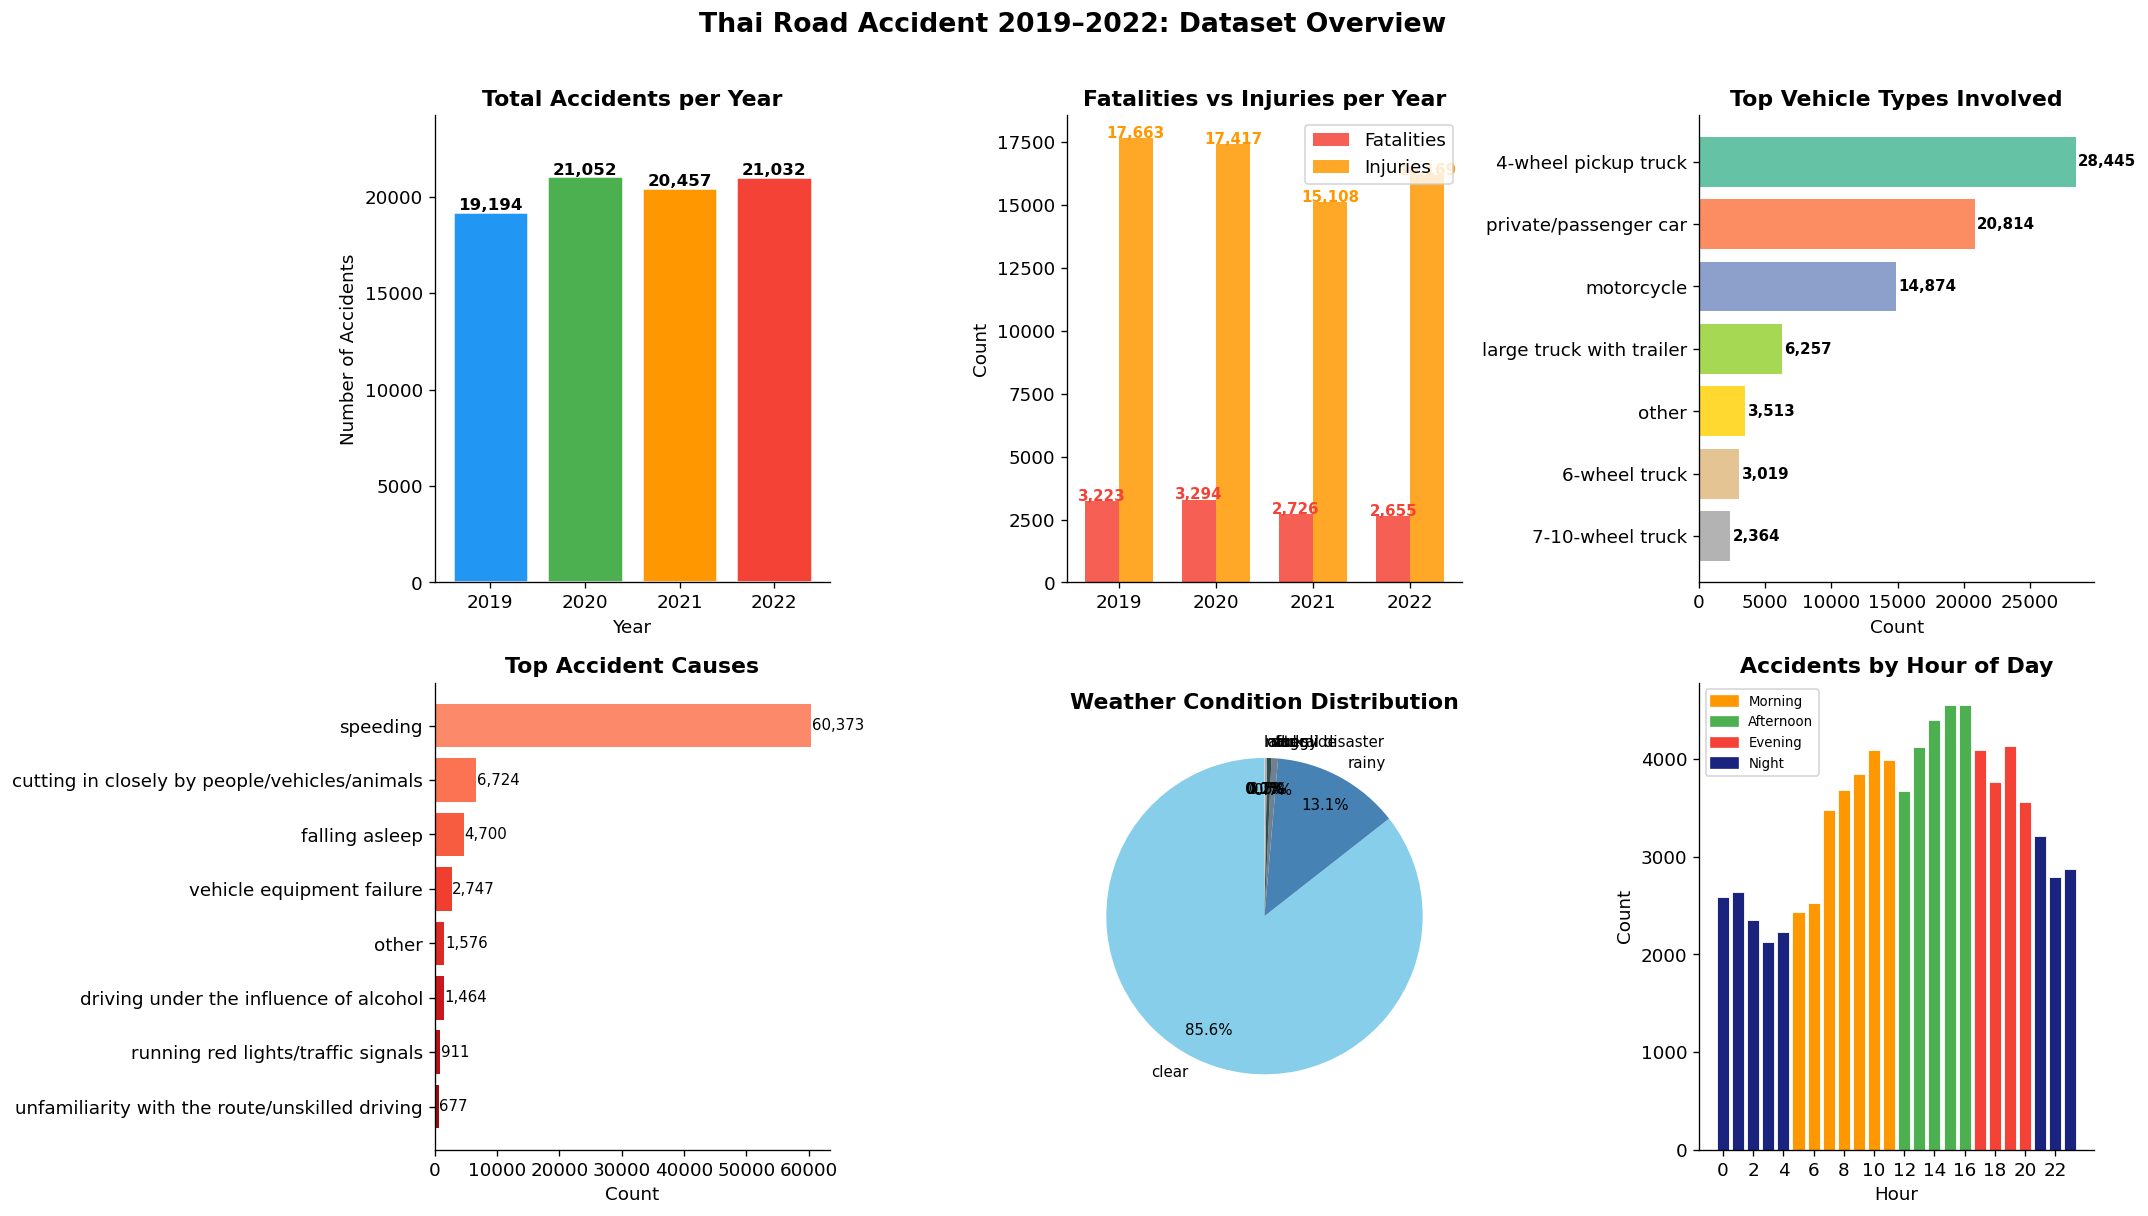

✅ Overview chart saved


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Thai Road Accident 2019–2022: Dataset Overview', fontsize=16, fontweight='bold', y=1.01)

colors_year = ['#2196F3','#4CAF50','#FF9800','#F44336']

# 1. Accidents per year
ax = axes[0,0]
year_cnt = df['year'].value_counts().sort_index()
bars = ax.bar(year_cnt.index, year_cnt.values, color=colors_year, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, year_cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+100, f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Total Accidents per Year', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Number of Accidents')
ax.set_ylim(0, year_cnt.max()*1.15)

# 2. Fatalities & Injuries per year
ax = axes[0,1]
fat_yr = df.groupby('year')['number_of_fatalities'].sum()
inj_yr = df.groupby('year')['number_of_injuries'].sum()
x = np.arange(4)
w = 0.35
b1 = ax.bar(x - w/2, fat_yr.values, w, label='Fatalities', color='#F44336', alpha=0.85)
b2 = ax.bar(x + w/2, inj_yr.values, w, label='Injuries', color='#FF9800', alpha=0.85)
for bar in b1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold', color='#F44336')
for bar in b2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10, f'{int(bar.get_height()):,}', ha='center', fontsize=9, fontweight='bold', color='#FF9800')
ax.set_title('Fatalities vs Injuries per Year', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([2019,2020,2021,2022])
ax.legend(); ax.set_ylabel('Count')

# 3. Vehicle Type
ax = axes[0,2]
veh = df['vehicle_type'].value_counts().head(7)
colors_veh = plt.cm.Set2(np.linspace(0, 1, len(veh)))
bars = ax.barh(veh.index[::-1], veh.values[::-1], color=colors_veh[::-1])
for bar, val in zip(bars, veh.values[::-1]):
    ax.text(bar.get_width()+200, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top Vehicle Types Involved', fontweight='bold')
ax.set_xlabel('Count')

# 4. Presumed Cause
ax = axes[1,0]
cause = df['presumed_cause'].value_counts().head(8)
colors_cause = plt.cm.Reds(np.linspace(0.4, 0.9, len(cause)))
bars = ax.barh(cause.index[::-1], cause.values[::-1], color=colors_cause[::-1])
for bar, val in zip(bars, cause.values[::-1]):
    ax.text(bar.get_width()+100, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontsize=9)
ax.set_title('Top Accident Causes', fontweight='bold')
ax.set_xlabel('Count')

# 5. Weather condition
ax = axes[1,1]
weath = df['weather_condition'].value_counts()
colors_w = ['#87CEEB','#4682B4','#708090','#2F4F4F','#A9A9A9','#D3D3D3','#F0F0F0']
wedges, texts, autotexts = ax.pie(weath.values, labels=weath.index, autopct='%1.1f%%',
                                   colors=colors_w[:len(weath)], startangle=90,
                                   pctdistance=0.8, textprops={'fontsize': 9})
ax.set_title('Weather Condition Distribution', fontweight='bold')

# 6. Time of Day
ax = axes[1,2]
hour_cnt = df['hour'].value_counts().sort_index()
colors_hour = ['#1a237e' if (h>=21 or h<5) else '#FF9800' if (5<=h<12) else '#4CAF50' if (12<=h<17) else '#F44336' for h in hour_cnt.index]
ax.bar(hour_cnt.index, hour_cnt.values, color=colors_hour, edgecolor='white', linewidth=0.5)
ax.set_title('Accidents by Hour of Day', fontweight='bold')
ax.set_xlabel('Hour'); ax.set_ylabel('Count')
ax.set_xticks(range(0,24,2))
legend_els = [mpatches.Patch(color='#FF9800',label='Morning'),
              mpatches.Patch(color='#4CAF50',label='Afternoon'),
              mpatches.Patch(color='#F44336',label='Evening'),
              mpatches.Patch(color='#1a237e',label='Night')]
ax.legend(handles=legend_els, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('01_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Overview chart saved')

## 3️⃣ Province Hotspot Analysis — จังหวัดเสี่ยงสูง (เทียบกับ Top Scorers NBA)

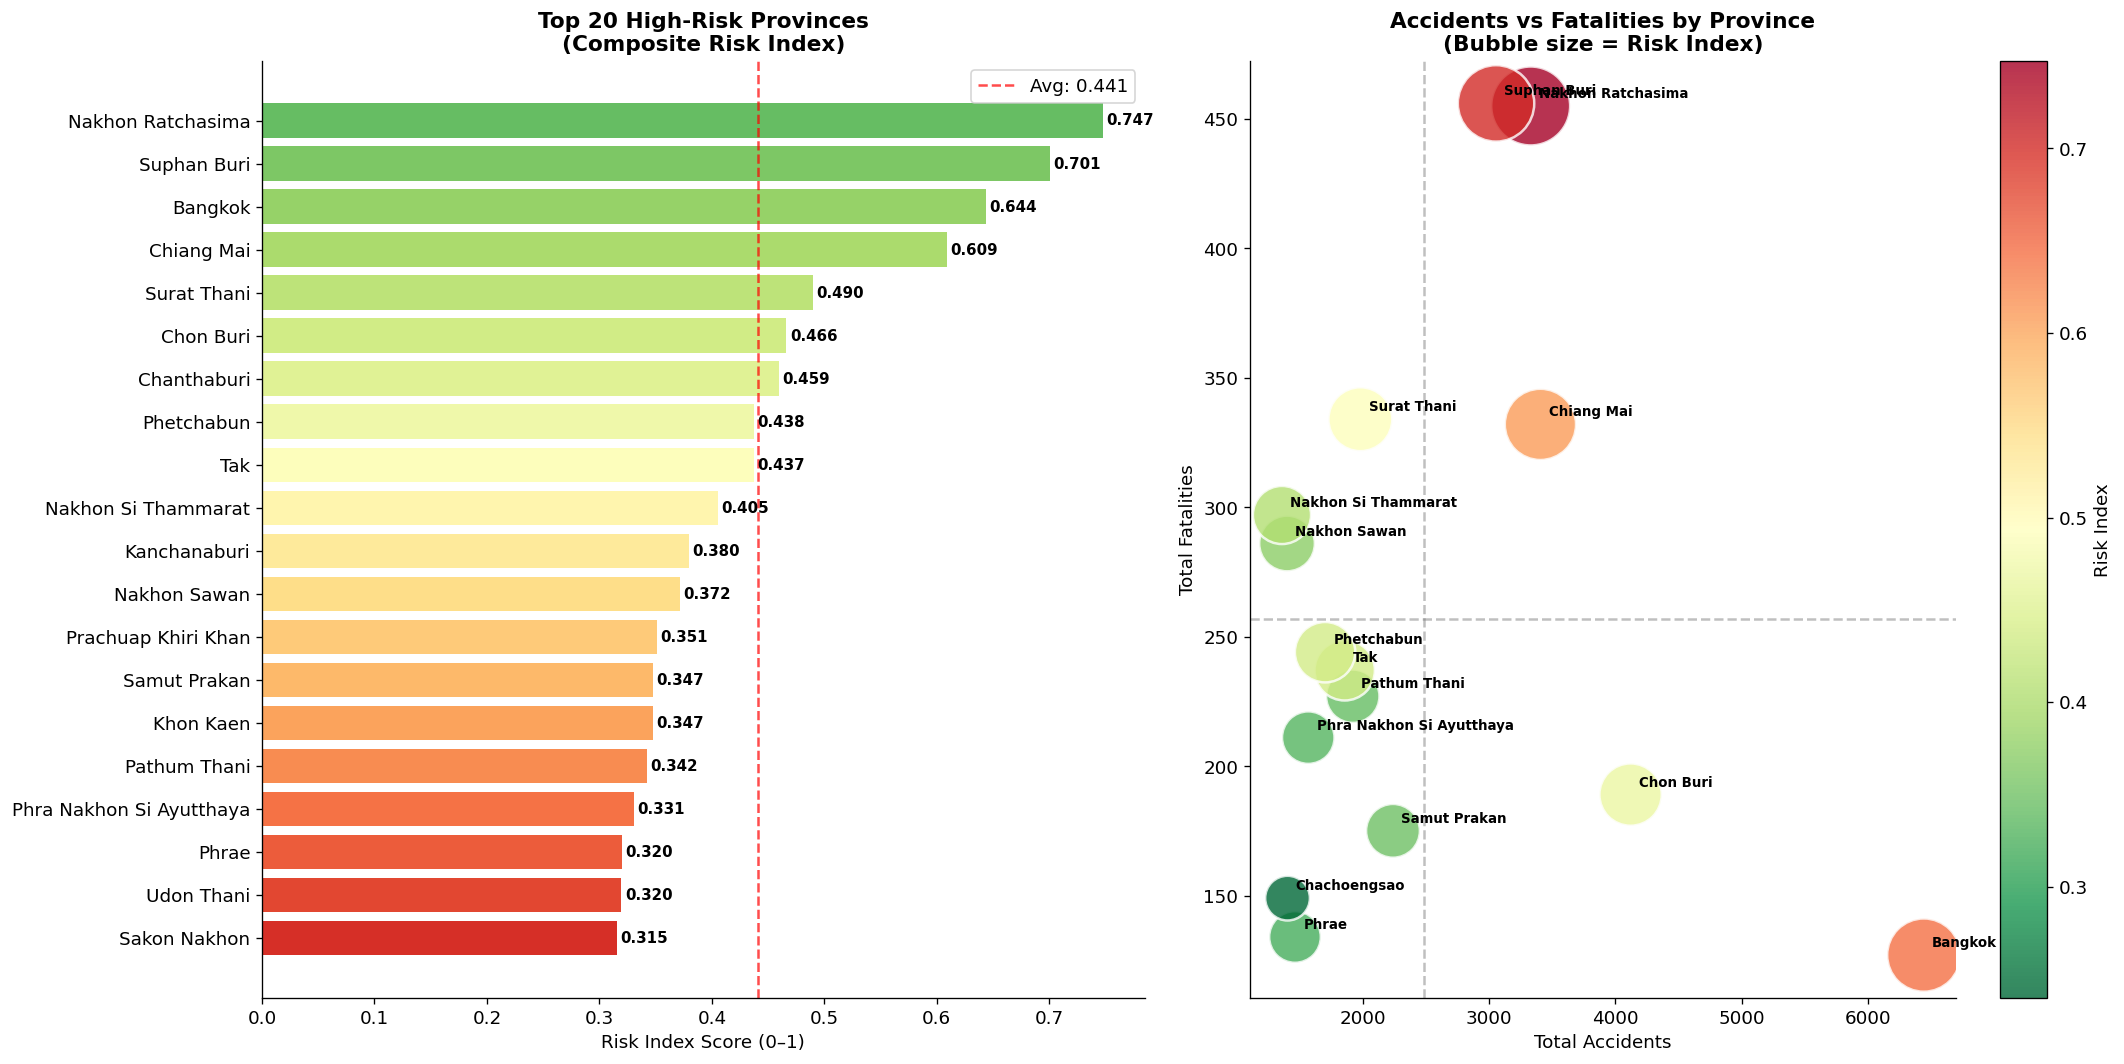


=== TOP 15 HIGH-RISK PROVINCES ===
        province_en  total_accidents  total_fatalities  total_injuries  avg_severity  risk_index
  Nakhon Ratchasima             3330               455            2982      1.305405    0.747472
        Suphan Buri             3056               456            2763      1.351767    0.700681
            Bangkok             6439               127            3122      0.544029    0.643669
         Chiang Mai             3407               332            2382      0.991488    0.609161
        Surat Thani             1983               334            1708      1.366616    0.489976
          Chon Buri             4120               189            1576      0.520146    0.466398
        Chanthaburi             1360               326            1489      1.813971    0.459393
         Phetchabun             1704               244            1615      1.377347    0.437815
                Tak             1859               237            1699      1.296396    0.4

In [ ]:
# Build Province Score (อิงสูตร NBA: Offense/Defense/Failure Score)
prov = df.groupby('province_en').agg(
    total_accidents  = ('acc_code', 'count'),
    total_fatalities = ('number_of_fatalities', 'sum'),
    total_injuries   = ('number_of_injuries', 'sum'),
    avg_severity     = ('severity_score', 'mean'),
    avg_road_risk    = ('road_risk_score', 'mean'),
    total_vehicles   = ('number_of_vehicles_involved', 'sum'),
).reset_index()

# Normalize 0–1
def norm(s): return (s - s.min()) / (s.max() - s.min())

prov['freq_score']     = norm(prov['total_accidents'])        # ความถี่
prov['fatal_score']    = norm(prov['total_fatalities'])       # ความรุนแรง (เสียชีวิต)
prov['injury_score']   = norm(prov['total_injuries'])         # บาดเจ็บ
prov['road_risk_norm'] = norm(prov['avg_road_risk'])          # ความเสี่ยงถนน

# Composite Risk Score = weighted sum (อิงสูตร NBA Two-Way Unicorn)
prov['risk_index'] = (
    0.35 * prov['freq_score'] +
    0.35 * prov['fatal_score'] +
    0.20 * prov['injury_score'] +
    0.10 * prov['road_risk_norm']
)

prov_top20 = prov.nlargest(20, 'risk_index')

# Plot: Top 20 Risk Index (เหมือน Top 10 Offensive Players NBA)
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: Risk Index
ax = axes[0]
colors_risk = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(prov_top20)))
bars = ax.barh(prov_top20['province_en'][::-1], prov_top20['risk_index'][::-1], color=colors_risk[::-1])
for bar, val in zip(bars, prov_top20['risk_index'].values[::-1]):
    ax.text(bar.get_width()+0.003, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontweight='bold', fontsize=9)
ax.set_title('Top 20 High-Risk Provinces\n(Composite Risk Index)', fontweight='bold', fontsize=13)
ax.set_xlabel('Risk Index Score (0–1)', fontsize=11)
ax.axvline(x=prov_top20['risk_index'].mean(), color='red', linestyle='--', alpha=0.7, label=f'Avg: {prov_top20["risk_index"].mean():.3f}')
ax.legend()

# Right: Fatality vs Accidents bubble chart
ax2 = axes[1]
top15 = prov.nlargest(15, 'total_accidents')
scatter = ax2.scatter(
    top15['total_accidents'],
    top15['total_fatalities'],
    s=top15['risk_index']*3000,
    c=top15['risk_index'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='white',
    linewidth=1.5
)
for _, row in top15.iterrows():
    ax2.annotate(row['province_en'], (row['total_accidents'], row['total_fatalities']),
                 textcoords='offset points', xytext=(5,5), fontsize=8, fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Risk Index')
ax2.set_title('Accidents vs Fatalities by Province\n(Bubble size = Risk Index)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Total Accidents'); ax2.set_ylabel('Total Fatalities')
ax2.axvline(x=top15['total_accidents'].mean(), color='gray', linestyle='--', alpha=0.5)
ax2.axhline(y=top15['total_fatalities'].mean(), color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('02_province_hotspot.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== TOP 15 HIGH-RISK PROVINCES ===')
display_cols = ['province_en','total_accidents','total_fatalities','total_injuries','avg_severity','risk_index']
print(prov.nlargest(15, 'risk_index')[display_cols].to_string(index=False))

## 4️⃣ Seasonal & Temporal Analysis — แนวโน้มตามเวลา

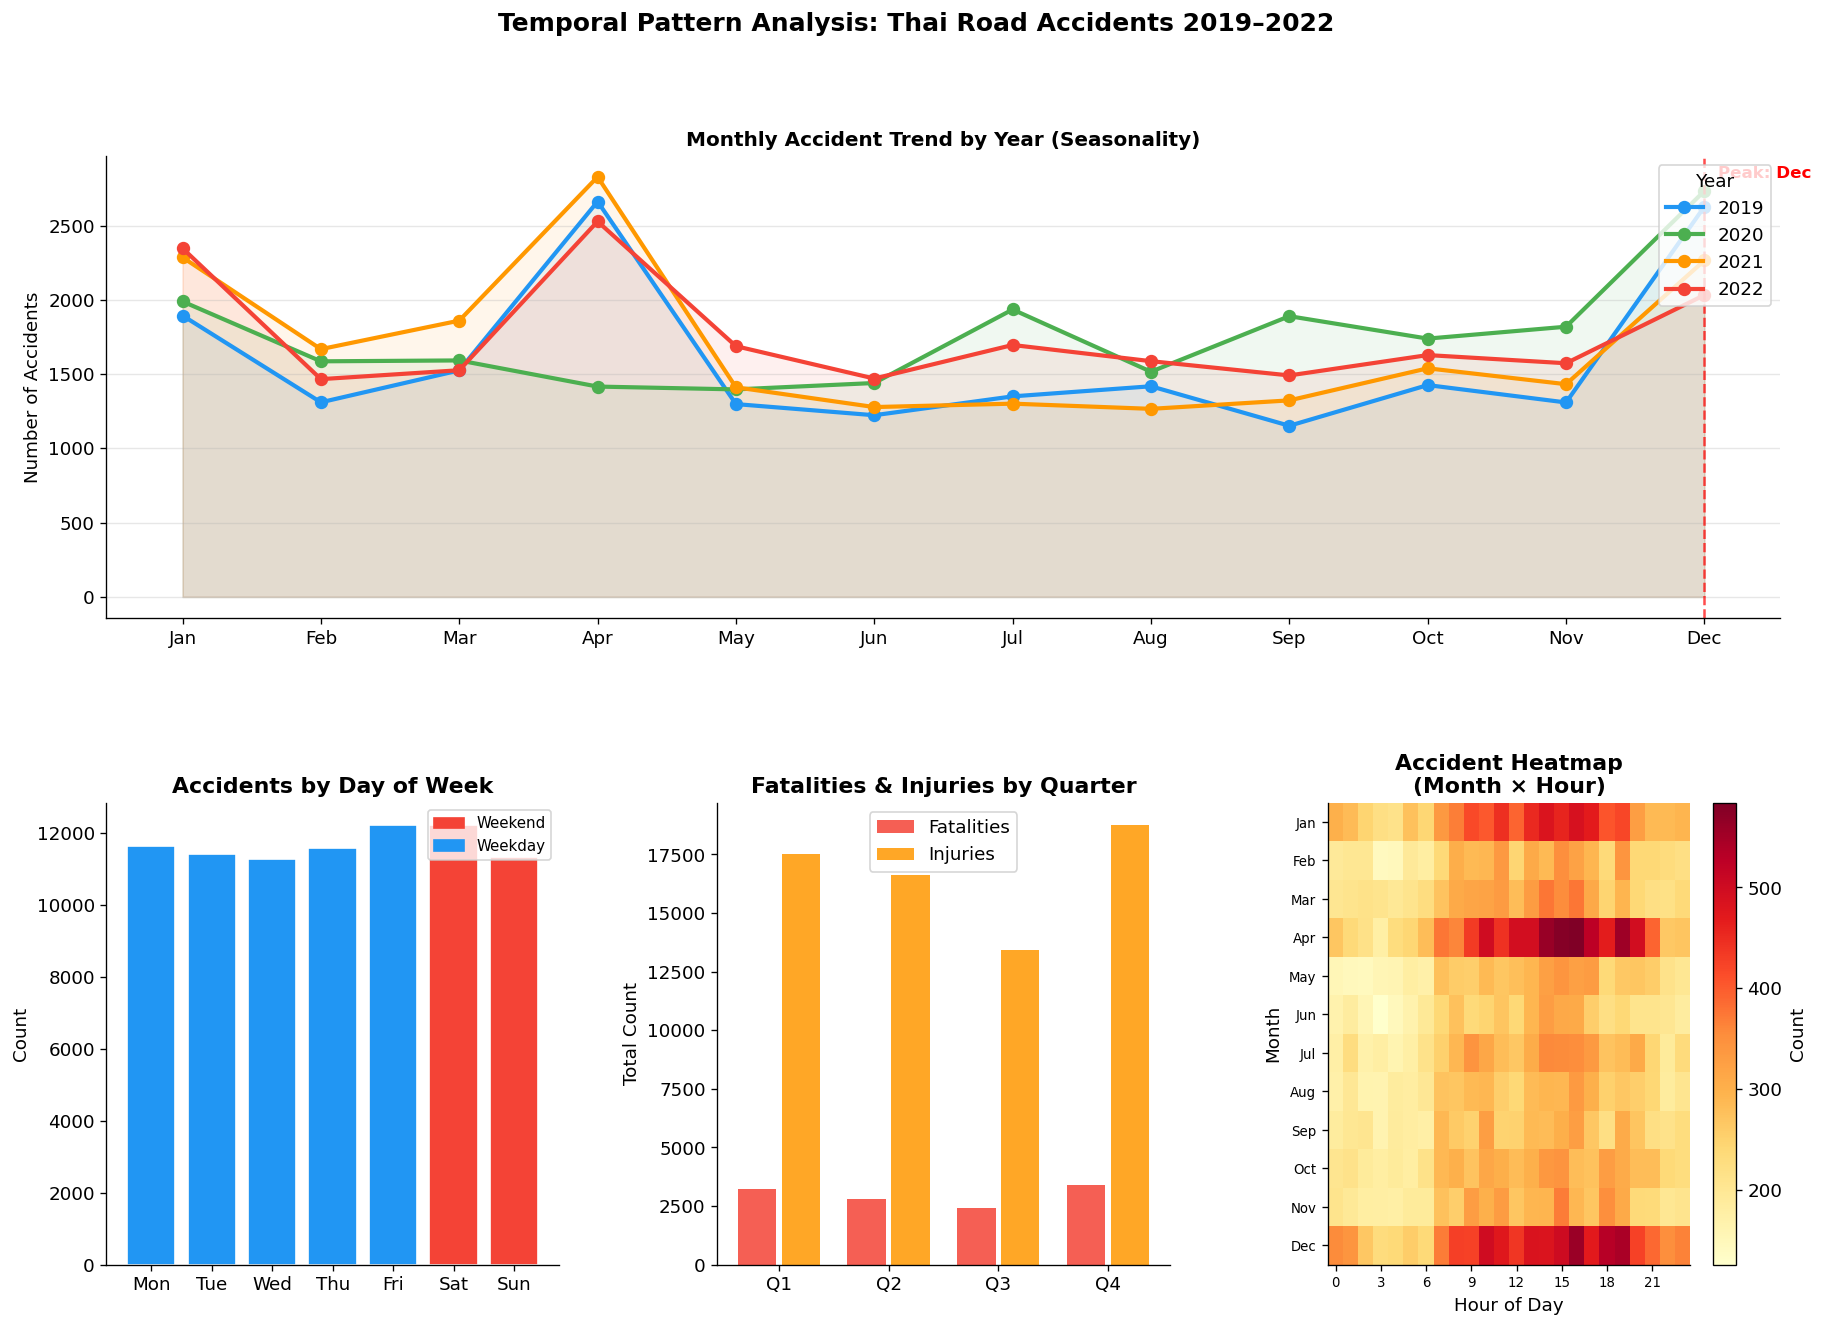

✅ Temporal analysis chart saved


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Temporal Pattern Analysis: Thai Road Accidents 2019–2022', fontsize=15, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Monthly trend by year (Line Chart — เหมือน Peak Age NBA)
ax1 = fig.add_subplot(gs[0, :])
colors_yr = {'2019':'#2196F3','2020':'#4CAF50','2021':'#FF9800','2022':'#F44336'}
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for yr in [2019,2020,2021,2022]:
    monthly = df[df['year']==yr].groupby('month').size()
    monthly = monthly.reindex(range(1,13), fill_value=0)
    ax1.plot(range(1,13), monthly.values, marker='o', linewidth=2.5,
             markersize=7, label=str(yr), color=colors_yr[str(yr)])
    ax1.fill_between(range(1,13), monthly.values, alpha=0.08, color=colors_yr[str(yr)])
ax1.set_title('Monthly Accident Trend by Year (Seasonality)', fontweight='bold', fontsize=12)
ax1.set_xticks(range(1,13)); ax1.set_xticklabels(month_labels)
ax1.set_ylabel('Number of Accidents')
ax1.legend(title='Year', loc='upper right')
ax1.grid(axis='y', alpha=0.3)
# Annotate peak
all_monthly = df.groupby('month').size()
peak_month = all_monthly.idxmax()
ax1.axvline(x=peak_month, color='red', linestyle='--', alpha=0.7)
ax1.text(peak_month+0.1, ax1.get_ylim()[1]*0.95, f'Peak: {month_labels[peak_month-1]}',
         color='red', fontweight='bold', fontsize=10)

# 2. Day of week
ax2 = fig.add_subplot(gs[1, 0])
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_cnt = df['dayofweek'].value_counts().sort_index()
bar_colors = ['#F44336' if d >= 5 else '#2196F3' for d in range(7)]
ax2.bar(day_labels, day_cnt.values, color=bar_colors, edgecolor='white')
ax2.set_title('Accidents by Day of Week', fontweight='bold')
ax2.set_ylabel('Count')
weekend_patch = mpatches.Patch(color='#F44336', label='Weekend')
weekday_patch = mpatches.Patch(color='#2196F3', label='Weekday')
ax2.legend(handles=[weekend_patch, weekday_patch], fontsize=9)

# 3. Quarter breakdown
ax3 = fig.add_subplot(gs[1, 1])
q_fat  = df.groupby('quarter')['number_of_fatalities'].sum()
q_inj  = df.groupby('quarter')['number_of_injuries'].sum()
x = np.arange(4)
ax3.bar(x-0.2, q_fat.values, 0.35, label='Fatalities', color='#F44336', alpha=0.85)
ax3.bar(x+0.2, q_inj.values, 0.35, label='Injuries', color='#FF9800', alpha=0.85)
ax3.set_xticks(x); ax3.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax3.set_title('Fatalities & Injuries by Quarter', fontweight='bold')
ax3.legend(); ax3.set_ylabel('Total Count')

# 4. Heatmap: Hour x Month
ax4 = fig.add_subplot(gs[1, 2])
heatmap_data = df.pivot_table(index='month', columns='hour', values='acc_code', aggfunc='count').fillna(0)
im = ax4.imshow(heatmap_data.values, aspect='auto', cmap='YlOrRd')
ax4.set_title('Accident Heatmap\n(Month × Hour)', fontweight='bold')
ax4.set_xlabel('Hour of Day'); ax4.set_ylabel('Month')
ax4.set_yticks(range(12)); ax4.set_yticklabels(month_labels, fontsize=8)
ax4.set_xticks(range(0,24,3)); ax4.set_xticklabels([0,3,6,9,12,15,18,21], fontsize=8)
plt.colorbar(im, ax=ax4, label='Count')

plt.savefig('03_temporal.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Temporal analysis chart saved')

## 5️⃣ Cause & Road Condition Analysis — วิเคราะห์สาเหตุและสภาพถนน

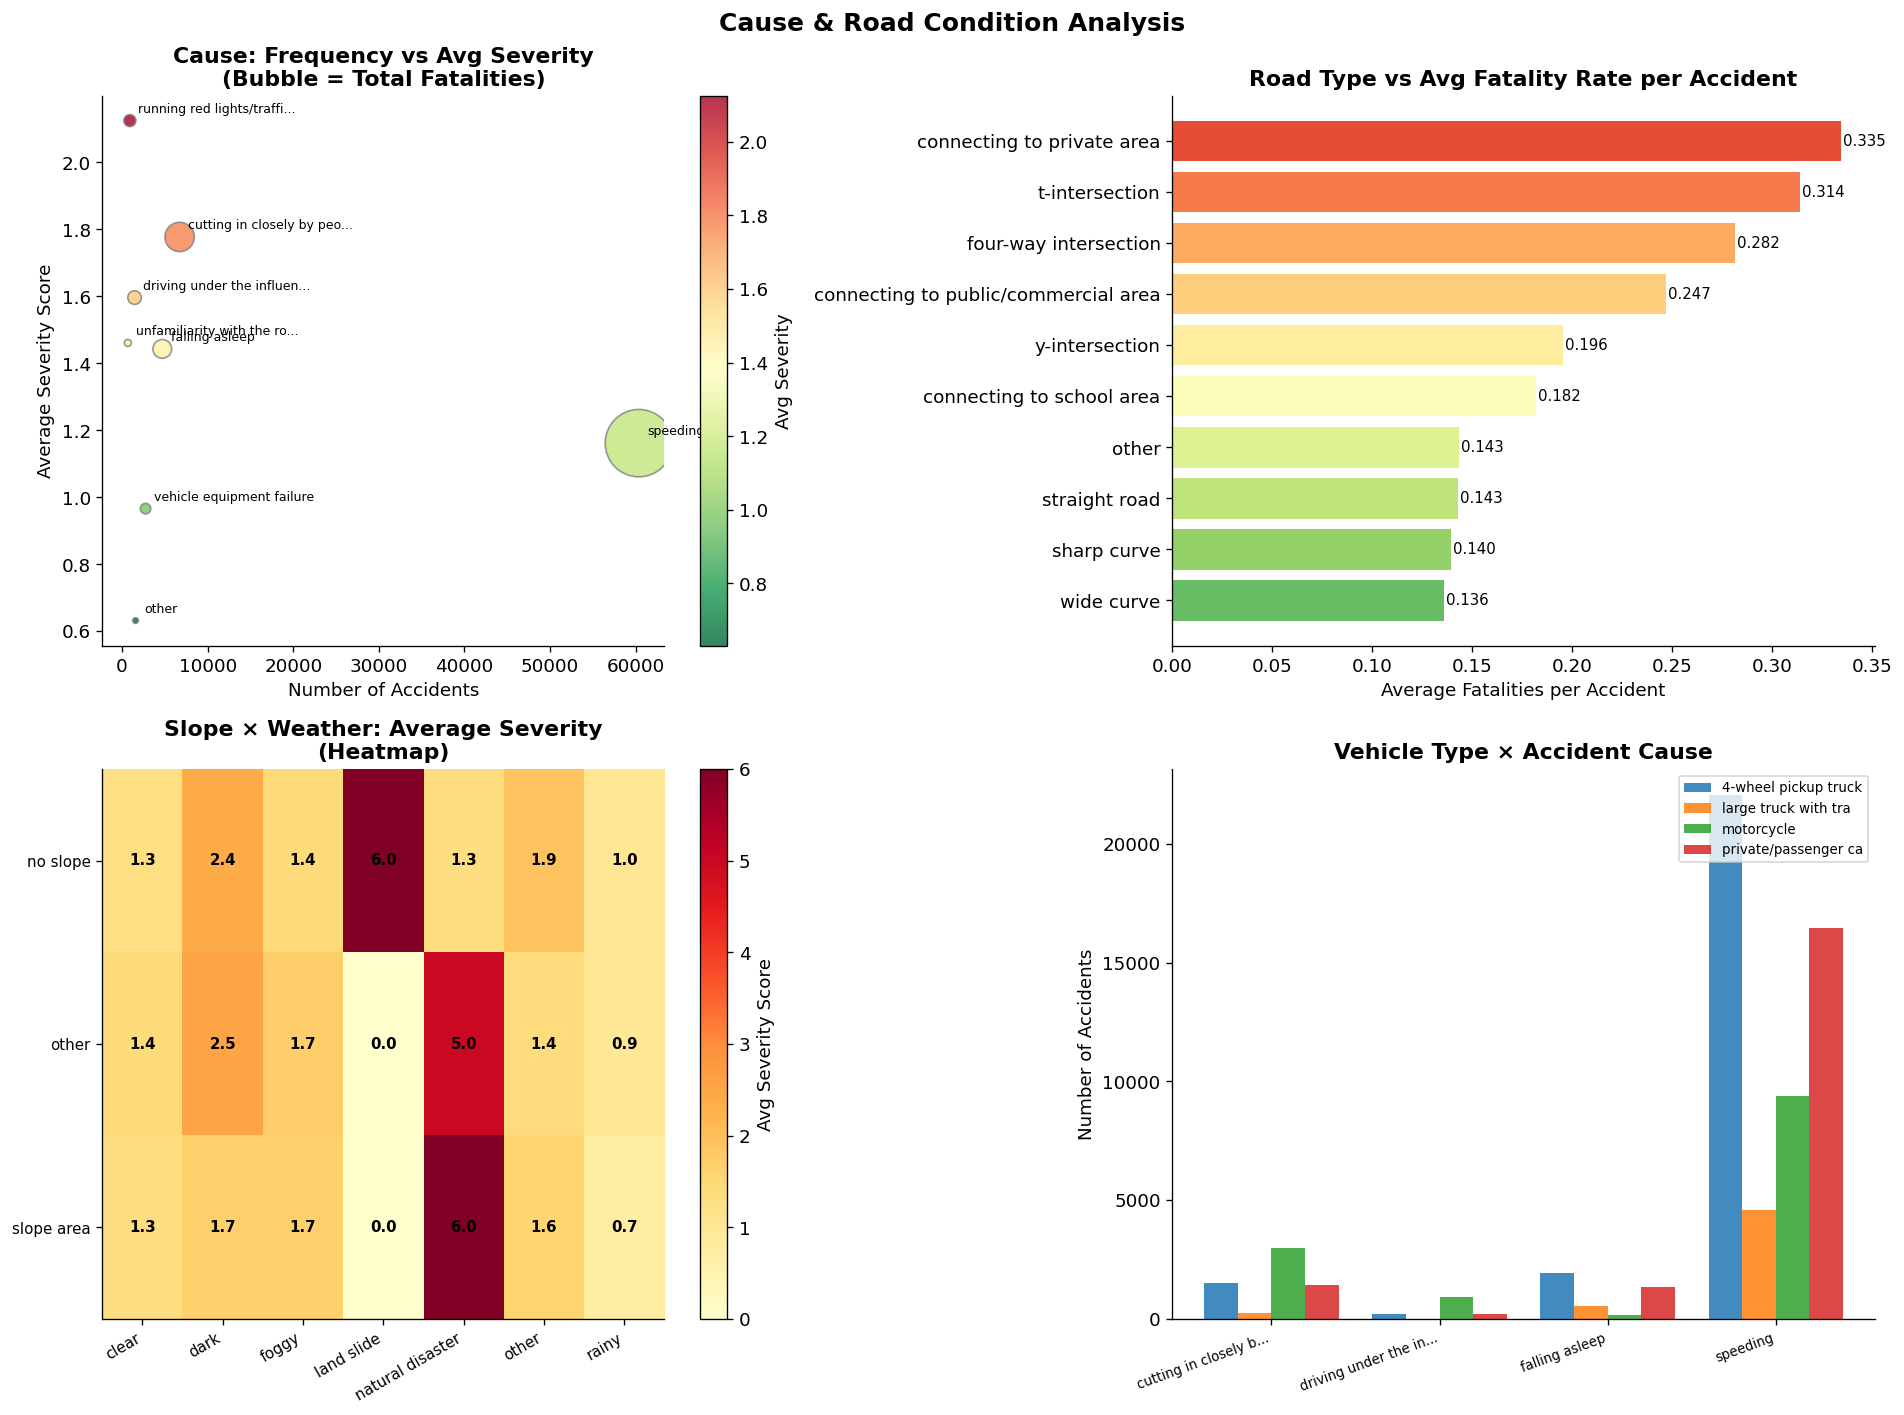

✅ Cause & road analysis saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Cause & Road Condition Analysis', fontsize=15, fontweight='bold')

# 1. Cause × Average Severity
ax = axes[0,0]
cause_sev = df.groupby('presumed_cause').agg(
    count=('acc_code','count'),
    avg_sev=('severity_score','mean'),
    total_fat=('number_of_fatalities','sum')
).nlargest(8,'count')
sc = ax.scatter(cause_sev['count'], cause_sev['avg_sev'],
                s=cause_sev['total_fat']/5, c=cause_sev['avg_sev'],
                cmap='RdYlGn_r', alpha=0.8, edgecolors='gray', linewidth=1)
for idx, row in cause_sev.iterrows():
    short = idx[:25]+'...' if len(idx)>25 else idx
    ax.annotate(short, (row['count'], row['avg_sev']), textcoords='offset points',
                xytext=(5,5), fontsize=7.5)
plt.colorbar(sc, ax=ax, label='Avg Severity')
ax.set_title('Cause: Frequency vs Avg Severity\n(Bubble = Total Fatalities)', fontweight='bold')
ax.set_xlabel('Number of Accidents'); ax.set_ylabel('Average Severity Score')

# 2. Road Description × Fatality Rate
ax = axes[0,1]
road_stats = df.groupby('road_description').agg(
    count=('acc_code','count'),
    fat_rate=('number_of_fatalities','mean')
).query('count > 50').sort_values('fat_rate', ascending=False).head(10)
colors_r = plt.cm.RdYlGn_r(np.linspace(0.2, 0.85, len(road_stats)))
bars = ax.barh(road_stats.index[::-1], road_stats['fat_rate'][::-1], color=colors_r)
for bar, val in zip(bars, road_stats['fat_rate'].values[::-1]):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Road Type vs Avg Fatality Rate per Accident', fontweight='bold')
ax.set_xlabel('Average Fatalities per Accident')

# 3. Slope × Weather → Severity Heatmap
ax = axes[1,0]
pivot = df.pivot_table(index='slope_description', columns='weather_condition',
                        values='severity_score', aggfunc='mean').fillna(0)
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f'{pivot.values[i,j]:.1f}', ha='center', va='center', fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, label='Avg Severity Score')
ax.set_title('Slope × Weather: Average Severity\n(Heatmap)', fontweight='bold')

# 4. Vehicle Type × Cause (Top 5 each)
ax = axes[1,1]
veh_cause = df[df['vehicle_type'].isin(df['vehicle_type'].value_counts().head(4).index)]
veh_cause = veh_cause[veh_cause['presumed_cause'].isin(['speeding','falling asleep','driving under the influence of alcohol','cutting in closely by people/vehicles/animals'])]
pivot2 = veh_cause.pivot_table(index='vehicle_type', columns='presumed_cause', values='acc_code', aggfunc='count').fillna(0)
x = np.arange(len(pivot2.columns))
w = 0.2
for i, (veh, row) in enumerate(pivot2.iterrows()):
    ax.bar(x + i*w, row.values, w, label=veh[:20], alpha=0.85)
ax.set_xticks(x + w*1.5)
short_causes = [c[:20]+'...' if len(c)>20 else c for c in pivot2.columns]
ax.set_xticklabels(short_causes, rotation=20, ha='right', fontsize=8)
ax.set_title('Vehicle Type × Accident Cause', fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylabel('Number of Accidents')

plt.tight_layout()
plt.savefig('04_cause_road.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Cause & road analysis saved')

## 6️⃣ Two-Way Risk Map — จังหวัดที่เสี่ยงทั้งความถี่ & ความรุนแรง (อิงแนวคิด Two-Way Unicorns)

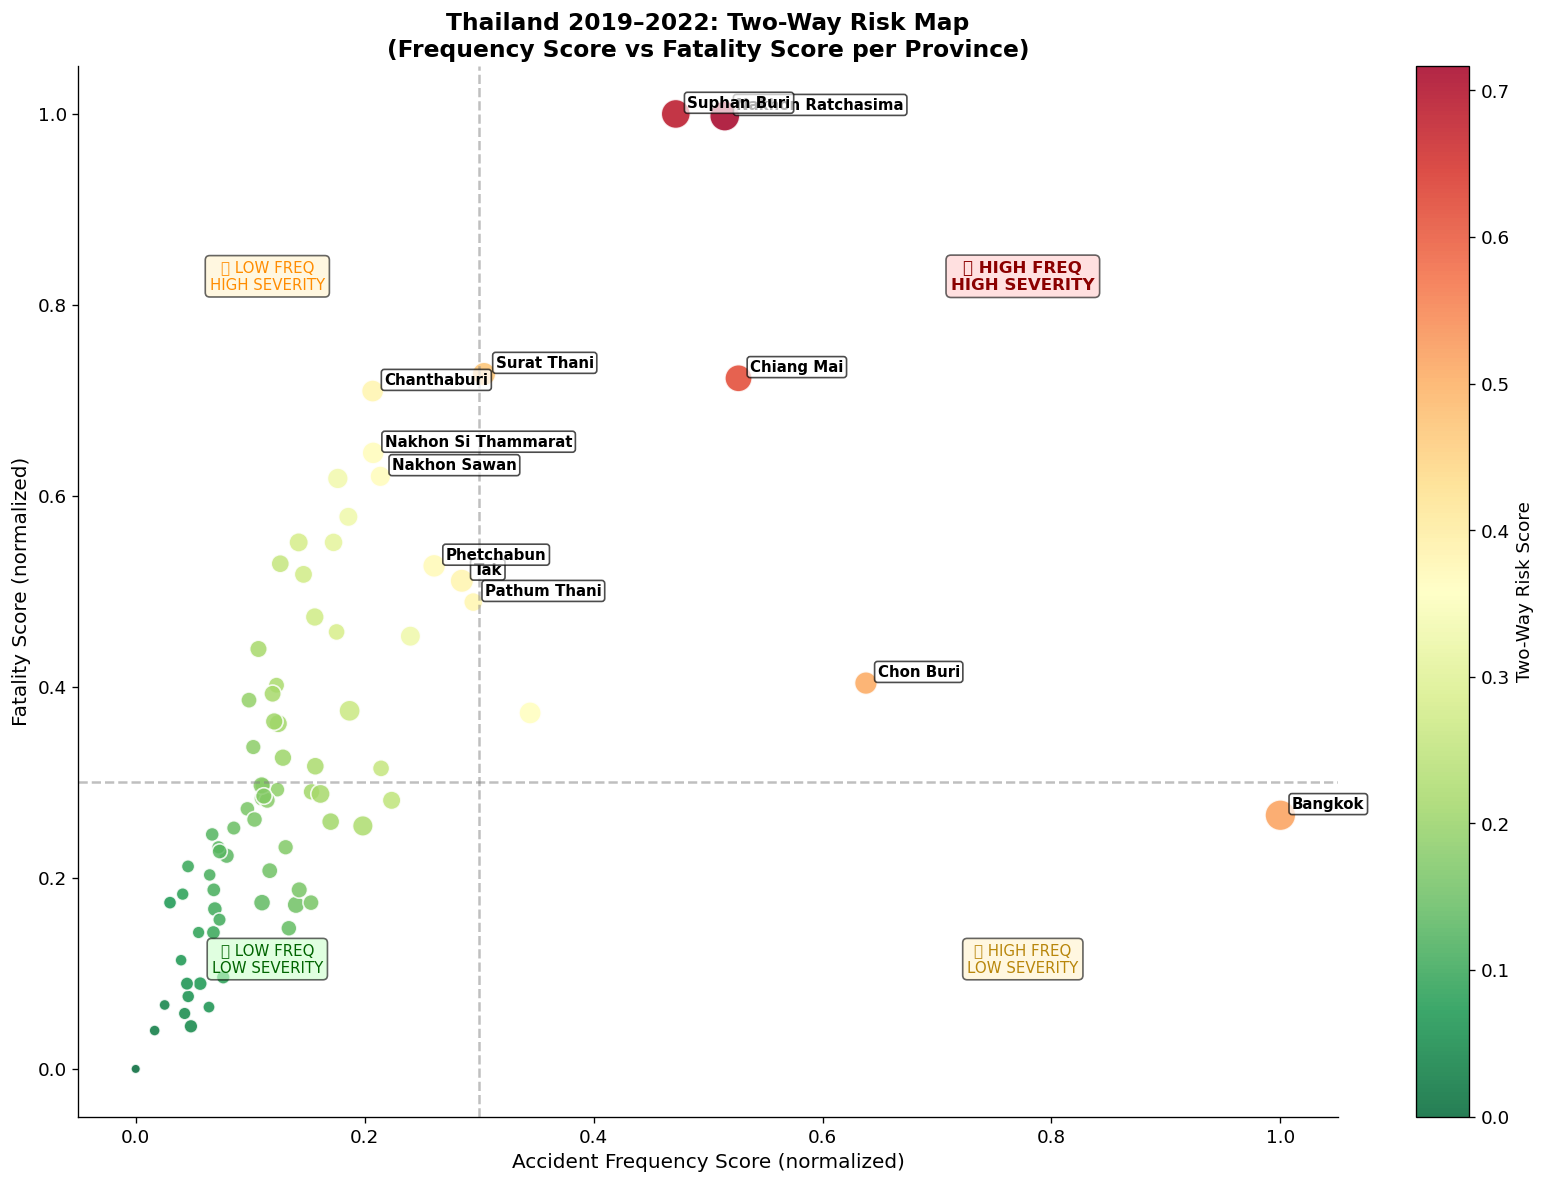


=== TWO-WAY RISK PROVINCES (TOP 15) ===
             province_en  total_accidents  total_fatalities  freq_score  fatal_score  twoway_score
       Nakhon Ratchasima             3330               455    0.514598     0.997768      0.716554
             Suphan Buri             3056               456    0.471819     1.000000      0.686891
              Chiang Mai             3407               332    0.526620     0.723214      0.617138
                 Bangkok             6439               127    1.000000     0.265625      0.515388
               Chon Buri             4120               189    0.637939     0.404018      0.507680
             Surat Thani             1983               334    0.304294     0.727679      0.470561
             Chanthaburi             1360               326    0.207026     0.709821      0.383342
                     Tak             1859               237    0.284934     0.511161      0.381637
            Pathum Thani             1923               227    0.294

In [ ]:
# Two-Way Score = sqrt(Frequency_norm × Severity_norm)
prov['twoway_score'] = np.sqrt(prov['freq_score'] * prov['fatal_score'])

fig, ax = plt.subplots(figsize=(14, 10))

# Scatter: x=freq_score, y=fatal_score, color=twoway_score, size=total_injuries
sc = ax.scatter(
    prov['freq_score'],
    prov['fatal_score'],
    s=prov['total_injuries']/10 + 30,
    c=prov['twoway_score'],
    cmap='RdYlGn_r',
    alpha=0.85,
    edgecolors='white',
    linewidth=1
)

# Label top provinces
top_label = prov.nlargest(12, 'twoway_score')
for _, row in top_label.iterrows():
    ax.annotate(row['province_en'],
                (row['freq_score'], row['fatal_score']),
                textcoords='offset points', xytext=(7,4),
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.colorbar(sc, ax=ax, label='Two-Way Risk Score')

# Quadrant lines
ax.axvline(x=0.3, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=0.3, color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
ax.text(0.75, 0.8, '🔴 HIGH FREQ\nHIGH SEVERITY', transform=ax.transAxes, fontsize=10,
        ha='center', va='center', color='darkred', fontweight='bold',
        bbox=dict(facecolor='#ffcccc', alpha=0.6, boxstyle='round'))
ax.text(0.15, 0.8, '🟡 LOW FREQ\nHIGH SEVERITY', transform=ax.transAxes, fontsize=9,
        ha='center', va='center', color='darkorange',
        bbox=dict(facecolor='#fff3cc', alpha=0.6, boxstyle='round'))
ax.text(0.75, 0.15, '🟠 HIGH FREQ\nLOW SEVERITY', transform=ax.transAxes, fontsize=9,
        ha='center', va='center', color='#b8860b',
        bbox=dict(facecolor='#fff3cc', alpha=0.6, boxstyle='round'))
ax.text(0.15, 0.15, '🟢 LOW FREQ\nLOW SEVERITY', transform=ax.transAxes, fontsize=9,
        ha='center', va='center', color='darkgreen',
        bbox=dict(facecolor='#ccffcc', alpha=0.6, boxstyle='round'))

ax.set_title('Thailand 2019–2022: Two-Way Risk Map\n(Frequency Score vs Fatality Score per Province)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Accident Frequency Score (normalized)', fontsize=12)
ax.set_ylabel('Fatality Score (normalized)', fontsize=12)

plt.tight_layout()
plt.savefig('05_twoway_risk.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== TWO-WAY RISK PROVINCES (TOP 15) ===')
print(prov.nlargest(15,'twoway_score')[['province_en','total_accidents','total_fatalities','freq_score','fatal_score','twoway_score']].to_string(index=False))

## 7️⃣ Regression Analysis — จังหวัดที่มีแนวโน้มแย่ลงเร็วที่สุด (อิง Slope Analysis NBA)

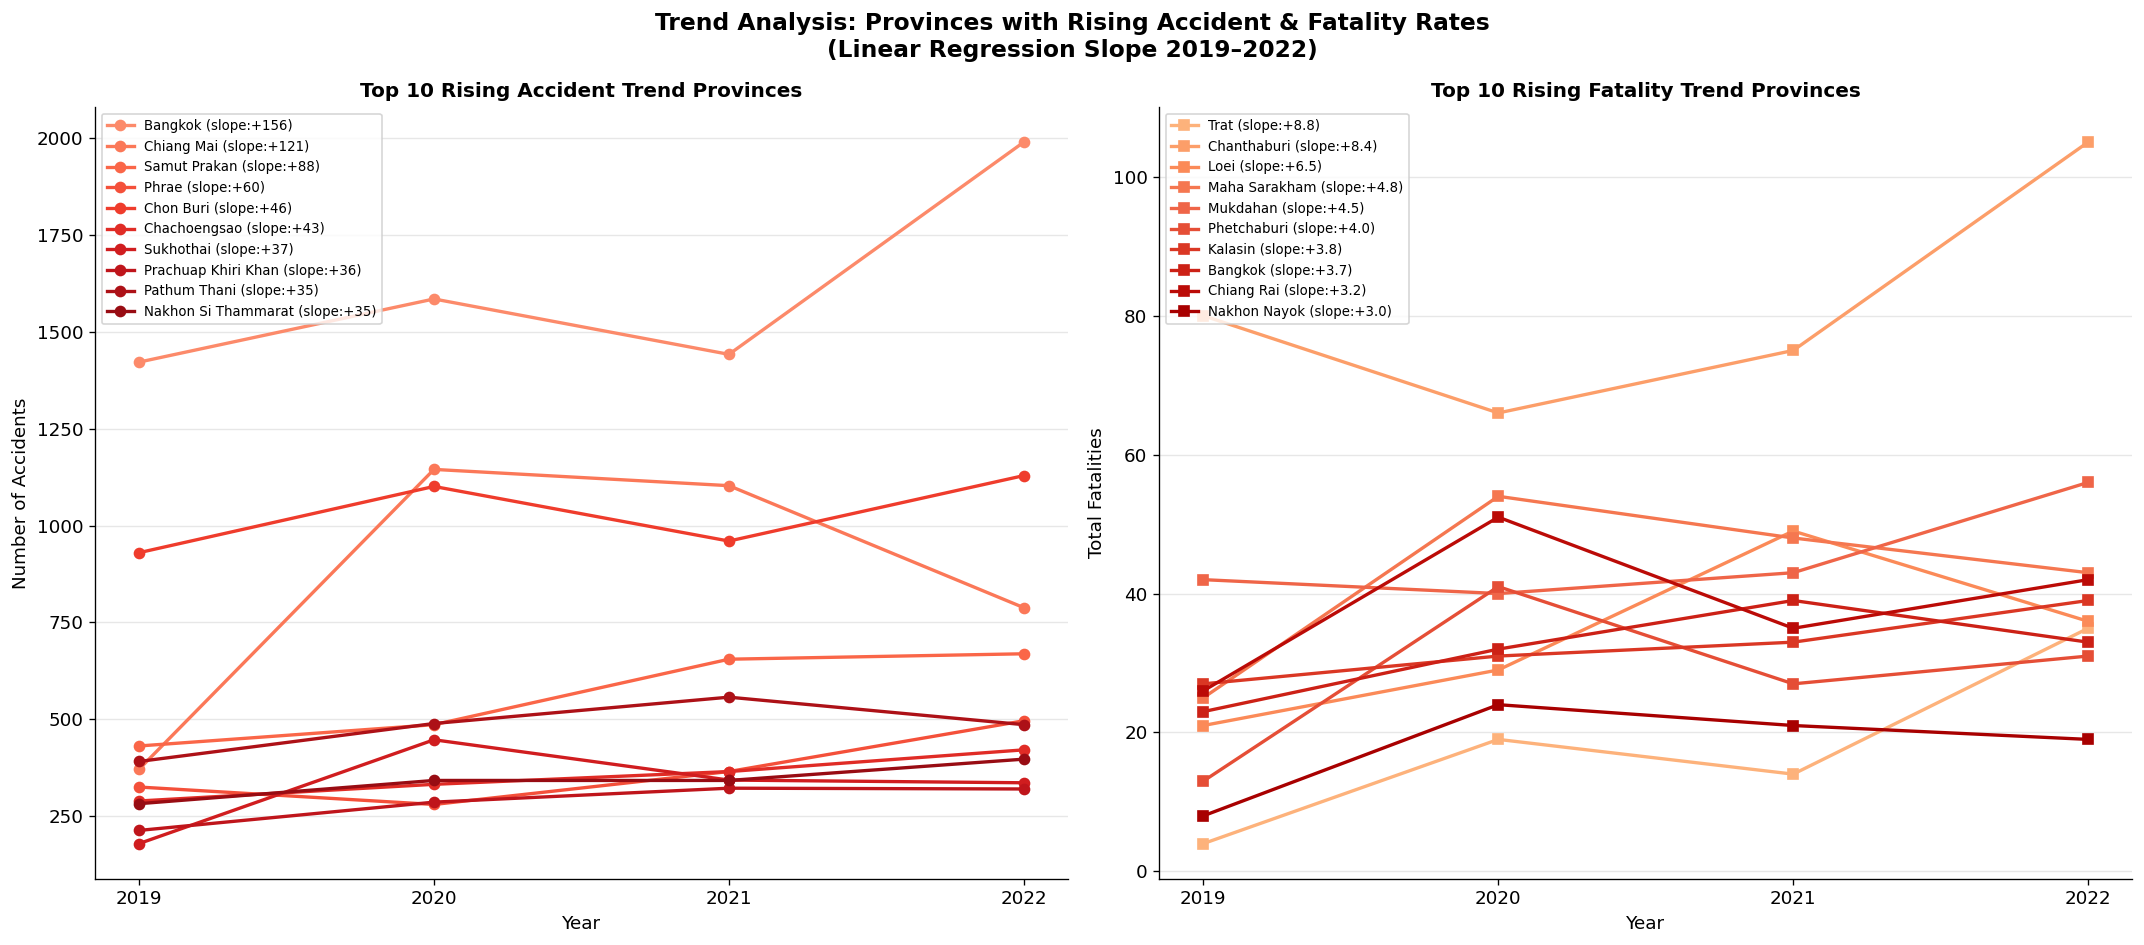


=== TOP 10 WORSENING PROVINCES (Accident Slope) ===
           province  slope       r2
            Bangkok  156.1 0.584086
         Chiang Mai  120.9 0.190171
       Samut Prakan   88.3 0.906136
              Phrae   59.8 0.688309
          Chon Buri   45.6 0.349566
       Chachoengsao   42.9 0.989601
          Sukhothai   36.7 0.183807
Prachuap Khiri Khan   35.7 0.819213
       Pathum Thani   35.3 0.446155
Nakhon Si Thammarat   34.5 0.899150


In [ ]:
# Regression: x=year, y=accident count per province (Slope = trend)
from sklearn.linear_model import LinearRegression
import numpy as np

prov_year = df.groupby(['province_en','year']).agg(
    accidents=('acc_code','count'),
    fatalities=('number_of_fatalities','sum'),
    severity=('severity_score','mean')
).reset_index()

results = []
for pname, grp in prov_year.groupby('province_en'):
    if len(grp) < 3: continue
    grp = grp.sort_values('year')
    X = grp['year'].values.reshape(-1,1)
    for metric in ['accidents','fatalities','severity']:
        y = grp[metric].values
        model = LinearRegression().fit(X, y)
        results.append({
            'province': pname,
            'metric': metric,
            'slope': model.coef_[0],
            'r2': r2_score(y, model.predict(X)) if len(grp)>2 else 0
        })

reg_df = pd.DataFrame(results)

# Top 10 worsening provinces by accident slope
acc_slope = reg_df[reg_df['metric']=='accidents'].nlargest(10, 'slope')
fat_slope = reg_df[reg_df['metric']=='fatalities'].nlargest(10, 'slope')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Trend Analysis: Provinces with Rising Accident & Fatality Rates\n(Linear Regression Slope 2019–2022)',
             fontsize=14, fontweight='bold')

# Left: Rising accident trend
ax = axes[0]
colors_slope = plt.cm.Reds(np.linspace(0.4, 0.9, len(acc_slope)))
# Plot lines for top provinces
for i, (_, row) in enumerate(acc_slope.iterrows()):
    pdata = prov_year[(prov_year['province_en']==row['province']) & (prov_year['year']>=2019)]
    ax.plot(pdata['year'], pdata['accidents'], marker='o', linewidth=2,
            label=f"{row['province']} (slope:{row['slope']:+.0f})", color=colors_slope[i])
ax.set_title('Top 10 Rising Accident Trend Provinces', fontweight='bold', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Number of Accidents')
ax.legend(fontsize=8, loc='upper left')
ax.set_xticks([2019,2020,2021,2022])
ax.grid(axis='y', alpha=0.3)

# Right: Rising fatality trend
ax = axes[1]
colors_fat = plt.cm.OrRd(np.linspace(0.4, 0.9, len(fat_slope)))
for i, (_, row) in enumerate(fat_slope.iterrows()):
    pdata = prov_year[(prov_year['province_en']==row['province']) & (prov_year['year']>=2019)]
    ax.plot(pdata['year'], pdata['fatalities'], marker='s', linewidth=2,
            label=f"{row['province']} (slope:{row['slope']:+.1f})", color=colors_fat[i])
ax.set_title('Top 10 Rising Fatality Trend Provinces', fontweight='bold', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Total Fatalities')
ax.legend(fontsize=8, loc='upper left')
ax.set_xticks([2019,2020,2021,2022])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('06_regression_trend.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== TOP 10 WORSENING PROVINCES (Accident Slope) ===')
print(acc_slope[['province','slope','r2']].to_string(index=False))

## 8️⃣ 🔮 Prediction 2023 — พยากรณ์จังหวัดที่เกิดอุบัติเหตุบ่อยสุด

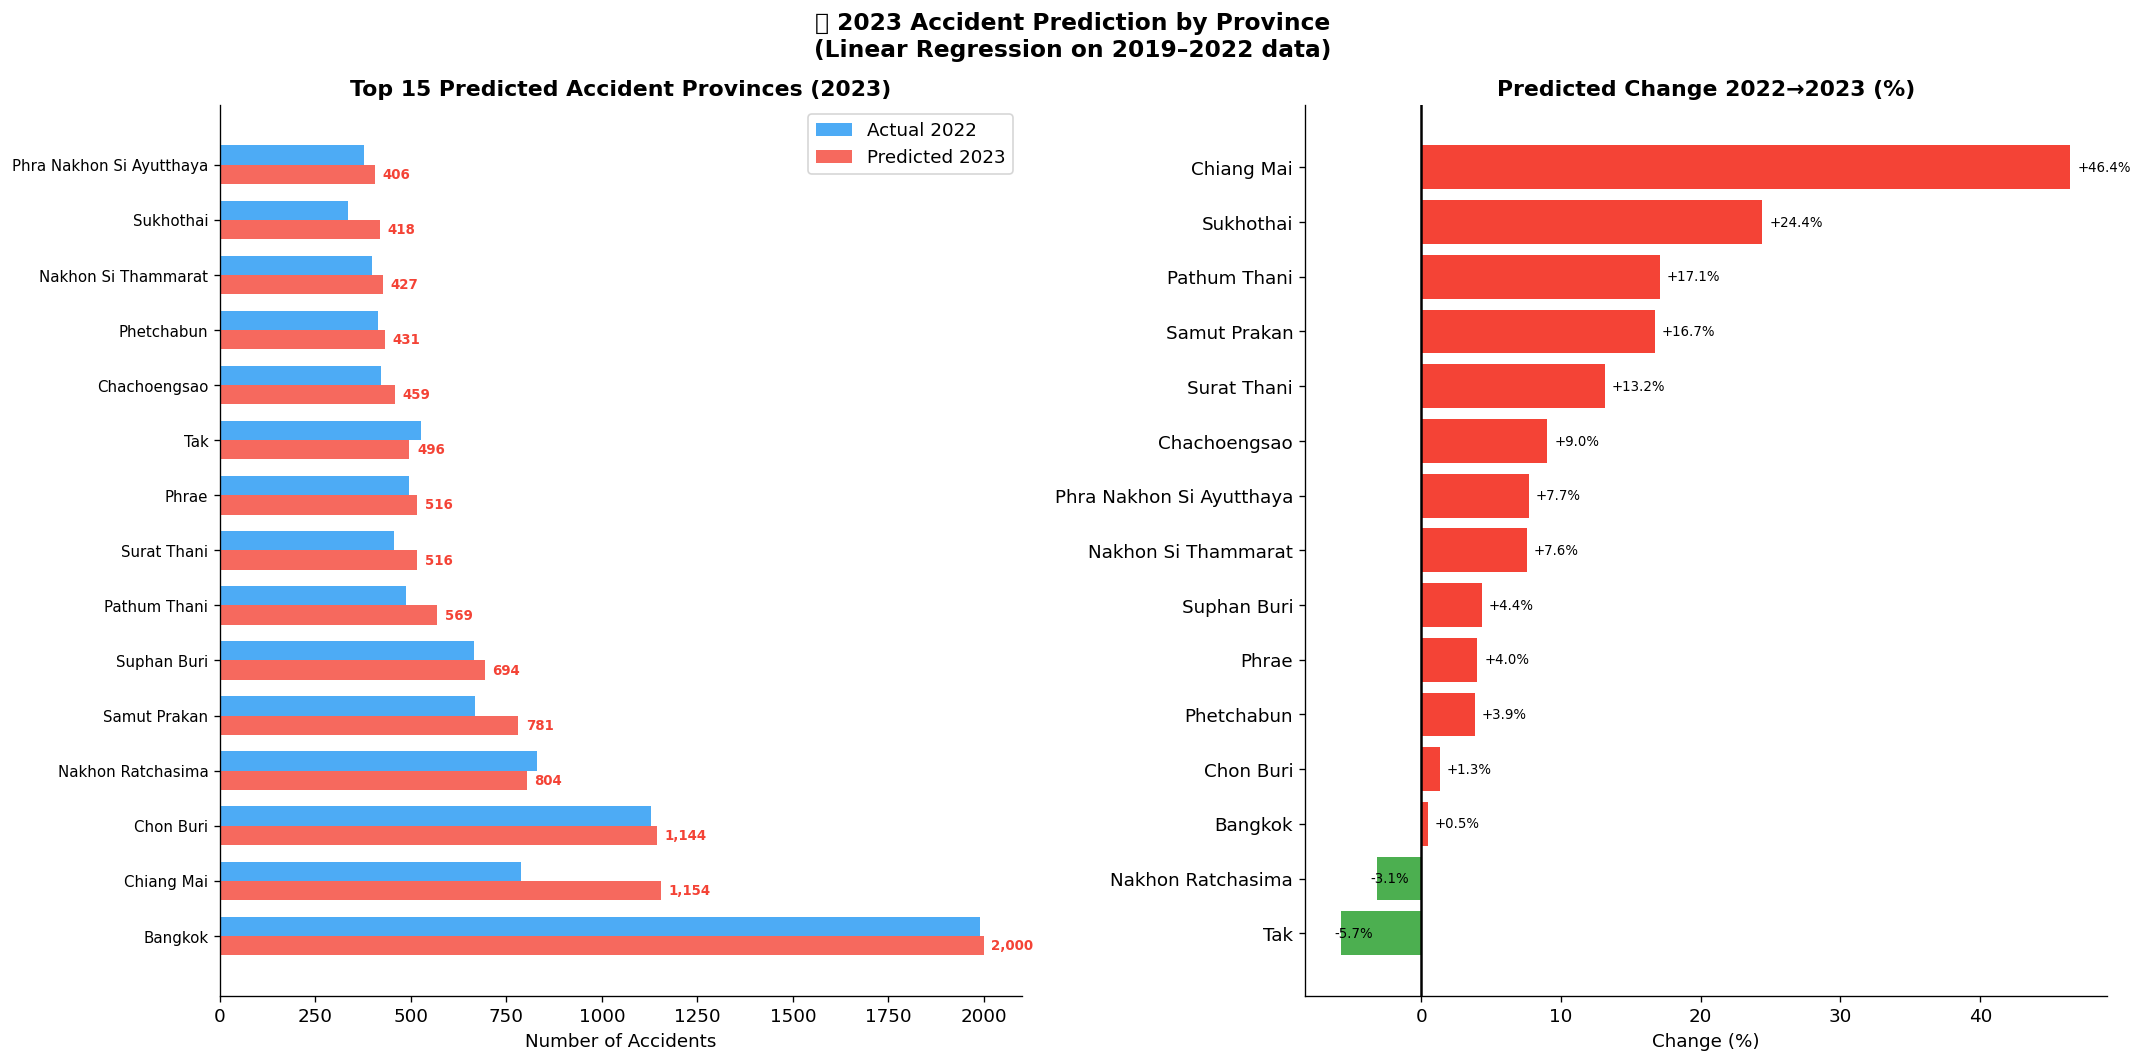


=== 🔮 TOP 20 PREDICTED HIGH-ACCIDENT PROVINCES IN 2023 ===
                province  actual_2022  pred_2023  slope     trend
                 Bangkok         1990       2000  156.1  Rising 📈
              Chiang Mai          788       1154  120.9  Rising 📈
               Chon Buri         1129       1144   45.6  Rising 📈
       Nakhon Ratchasima          830        804  -11.6 Falling 📉
            Samut Prakan          669        781   88.3  Rising 📈
             Suphan Buri          665        694  -28.2 Falling 📉
            Pathum Thani          486        569   35.3  Rising 📈
             Surat Thani          456        516    8.3 Stable ➡️
                   Phrae          496        516   59.8  Rising 📈
                     Tak          526        496   12.7  Rising 📈
            Chachoengsao          421        459   42.9  Rising 📈
              Phetchabun          415        431    2.0 Stable ➡️
     Nakhon Si Thammarat          397        427   34.5  Rising 📈
               S

In [ ]:
# Predict 2023 accident count per province using Linear Regression on 2019-2022
pred_results = []
for pname, grp in prov_year.groupby('province_en'):
    if len(grp) < 3: continue
    grp = grp.sort_values('year')
    X = grp['year'].values.reshape(-1,1)
    y = grp['accidents'].values
    model = LinearRegression().fit(X, y)
    pred_2023 = max(0, model.predict([[2023]])[0])
    actual_2022 = grp[grp['year']==2022]['accidents'].values
    actual_2022 = actual_2022[0] if len(actual_2022)>0 else 0
    trend = 'Rising 📈' if model.coef_[0] > 10 else ('Falling 📉' if model.coef_[0] < -10 else 'Stable ➡️')
    pred_results.append({
        'province': pname,
        'pred_2023': round(pred_2023),
        'actual_2022': actual_2022,
        'slope': round(model.coef_[0], 1),
        'trend': trend
    })

pred_df = pd.DataFrame(pred_results).sort_values('pred_2023', ascending=False)
top_pred = pred_df.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
fig.suptitle('🔮 2023 Accident Prediction by Province\n(Linear Regression on 2019–2022 data)',
             fontsize=14, fontweight='bold')

# Left: Bar chart prediction vs 2022 actual
ax = axes[0]
x = np.arange(len(top_pred))
w = 0.35
bars1 = ax.barh(x+w/2, top_pred['actual_2022'], w, label='Actual 2022', color='#2196F3', alpha=0.8)
bars2 = ax.barh(x-w/2, top_pred['pred_2023'], w, label='Predicted 2023', color='#F44336', alpha=0.8)
ax.set_yticks(x); ax.set_yticklabels(top_pred['province'], fontsize=9)
ax.set_title('Top 15 Predicted Accident Provinces (2023)', fontweight='bold')
ax.set_xlabel('Number of Accidents')
ax.legend()
for bar, val in zip(bars2, top_pred['pred_2023']):
    ax.text(bar.get_width()+20, bar.get_y()+bar.get_height()/2, f'{int(val):,}', va='center', fontsize=8, color='#F44336', fontweight='bold')

# Right: Predicted change % (Rise/Fall)
ax = axes[1]
top_pred['change_pct'] = ((top_pred['pred_2023'] - top_pred['actual_2022']) / top_pred['actual_2022'].replace(0,1)) * 100
sorted_chg = top_pred.sort_values('change_pct', ascending=False).head(20)
colors_chg = ['#F44336' if v > 0 else '#4CAF50' for v in sorted_chg['change_pct']]
bars = ax.barh(sorted_chg['province'][::-1], sorted_chg['change_pct'][::-1], color=colors_chg[::-1])
ax.axvline(x=0, color='black', linewidth=1.5)
for bar, val in zip(bars, sorted_chg['change_pct'].values[::-1]):
    offset = 0.5 if val >= 0 else -0.5
    ax.text(bar.get_width()+offset, bar.get_y()+bar.get_height()/2, f'{val:+.1f}%', va='center', fontsize=8)
ax.set_title('Predicted Change 2022→2023 (%)', fontweight='bold')
ax.set_xlabel('Change (%)')

plt.tight_layout()
plt.savefig('07_prediction.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== 🔮 TOP 20 PREDICTED HIGH-ACCIDENT PROVINCES IN 2023 ===')
print(pred_df.head(20)[['province','actual_2022','pred_2023','slope','trend']].to_string(index=False))

## 9️⃣ Province Clustering — แบ่งกลุ่มจังหวัดตามลักษณะอุบัติเหตุ (อิง K-Means Clustering NBA)

  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


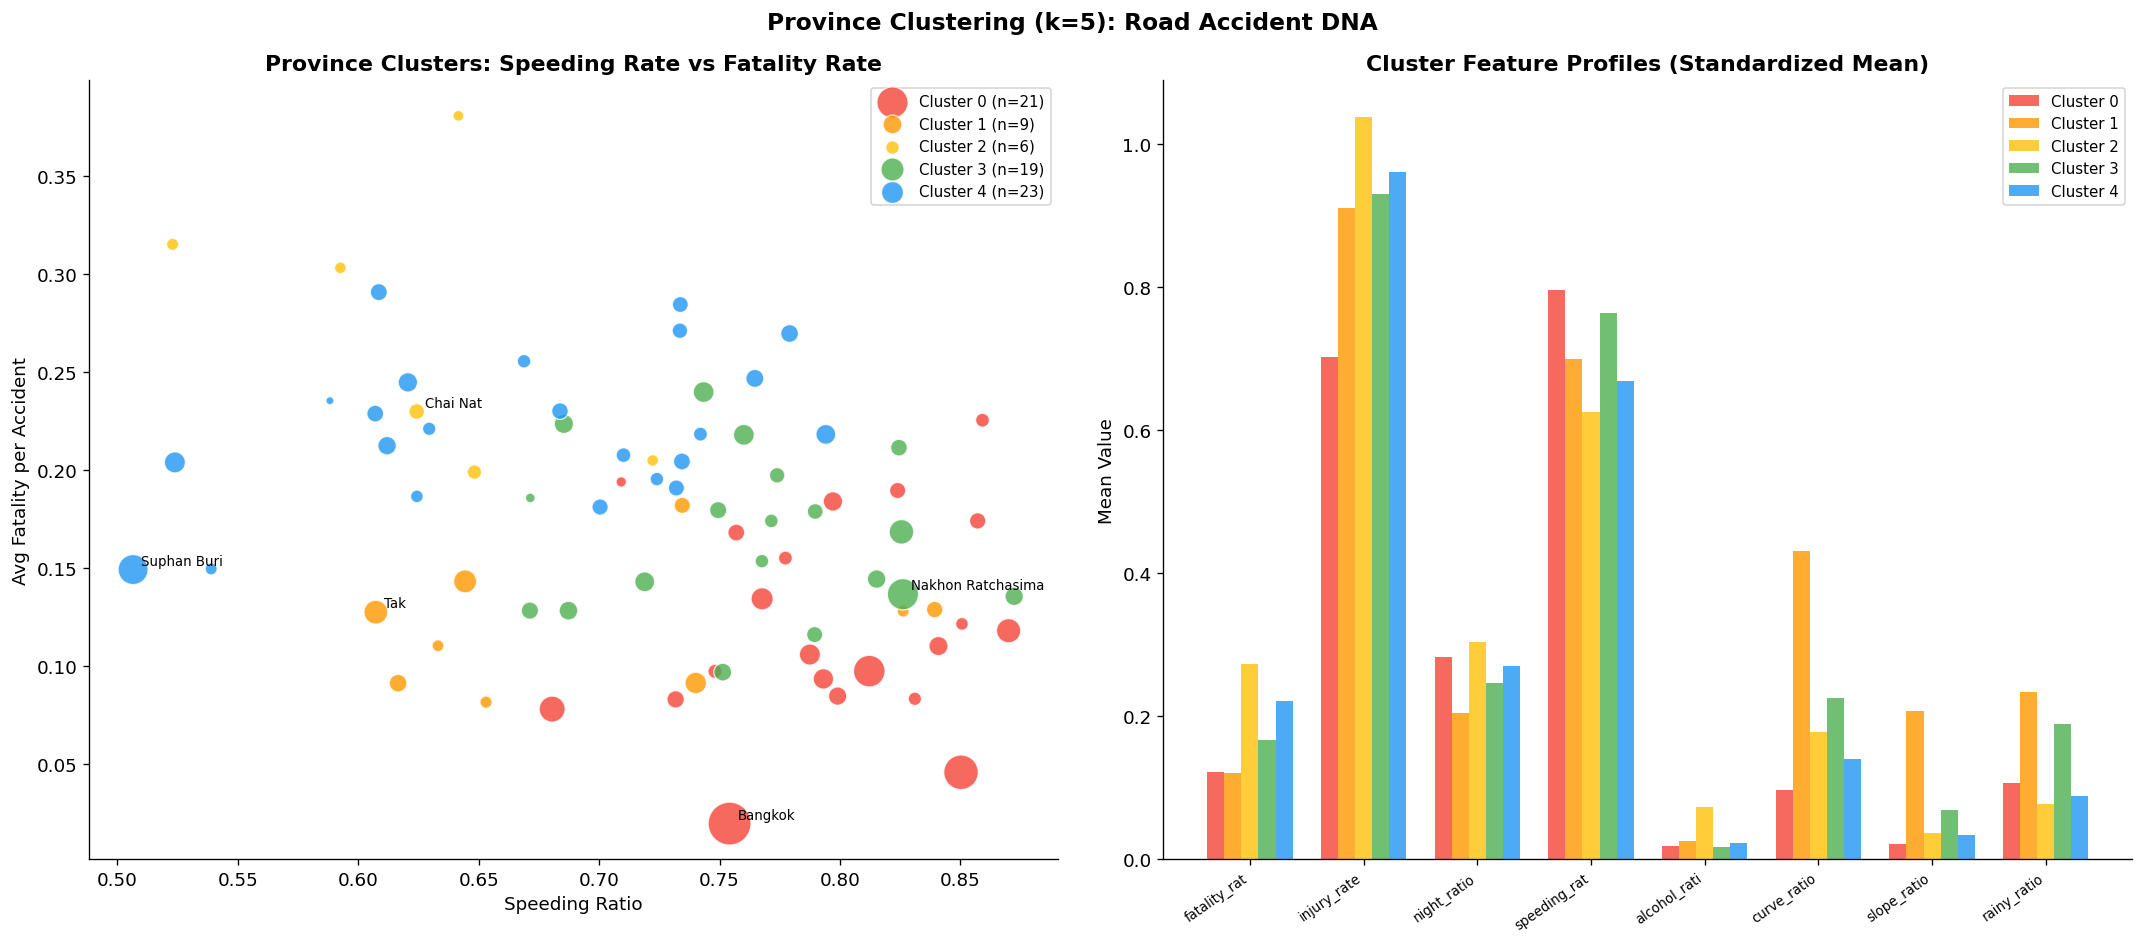


=== CLUSTER ASSIGNMENTS ===

Cluster 0 (avg fatality_rate=0.122): 21 provinces
Amnat Charoen, Ang Thong, Bangkok, Chachoengsao, Chiang Mai, Chon Buri, Lamphun, Nakhon Pathom, Nonthaburi, Pathum Thani...

Cluster 1 (avg fatality_rate=0.120): 9 provinces
Loei, Mae Hong Son, Nan, Phangnga, Phetchabun, Phrae, Tak, Trang, Yala

Cluster 2 (avg fatality_rate=0.272): 6 provinces
Buri Ram, Chai Nat, Nong Bua Lam Phu, Nong Khai, Phayao, Phichit

Cluster 3 (avg fatality_rate=0.166): 19 provinces
Chanthaburi, Chiang Rai, Chumphon, Kalasin, Krabi, Lampang, Nakhon Ratchasima, Nakhon Si Thammarat, Narathiwat, Phatthalung...

Cluster 4 (avg fatality_rate=0.221): 23 provinces
Chaiyaphum, Kamphaeng Phet, Kanchanaburi, Khon Kaen, Loburi, Maha Sarakham, Mukdahan, Nakhon Nayok, Nakhon Phanom, Nakhon Sawan...


In [ ]:
# Province-level features for clustering
prov_feat = df.groupby('province_en').agg(
    total_accidents      = ('acc_code','count'),
    fatality_rate        = ('number_of_fatalities','mean'),
    injury_rate          = ('number_of_injuries','mean'),
    night_ratio          = ('hour', lambda x: ((x>=21)|(x<5)).mean()),
    speeding_ratio       = ('presumed_cause', lambda x: (x=='speeding').mean()),
    alcohol_ratio        = ('presumed_cause', lambda x: (x=='driving under the influence of alcohol').mean()),
    curve_ratio          = ('road_description', lambda x: x.isin(['wide curve','sharp curve']).mean()),
    slope_ratio          = ('slope_description', lambda x: (x=='slope area').mean()),
    rainy_ratio          = ('weather_condition', lambda x: (x=='rainy').mean()),
).dropna()

features = ['fatality_rate','injury_rate','night_ratio','speeding_ratio','alcohol_ratio','curve_ratio','slope_ratio','rainy_ratio']
X = prov_feat[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
prov_feat['cluster'] = kmeans.fit_predict(X_scaled)

# Cluster descriptions
cluster_labels = {
    0: 'Cluster 0: Urban High-Freq',
    1: 'Cluster 1: Highway Fatal',
    2: 'Cluster 2: Mountain Curve',
    3: 'Cluster 3: Balanced Risk',
    4: 'Cluster 4: Low Risk'
}

# Rename clusters by fatality_rate
cluster_stats = prov_feat.groupby('cluster')['fatality_rate'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Province Clustering (k=5): Road Accident DNA', fontsize=14, fontweight='bold')

# Left: Cluster distribution
ax = axes[0]
colors_cl = ['#F44336','#FF9800','#FFC107','#4CAF50','#2196F3']
for cl in range(5):
    subset = prov_feat[prov_feat['cluster']==cl]
    ax.scatter(
        subset['speeding_ratio'], subset['fatality_rate'],
        s=subset['total_accidents']/10+20,
        color=colors_cl[cl], alpha=0.8, edgecolors='white', linewidth=0.8,
        label=f'Cluster {cl} (n={len(subset)})'
    )
    # Label top province per cluster
    top_prov = subset.nlargest(1,'total_accidents')
    for _, row in top_prov.iterrows():
        ax.annotate(row.name, (row['speeding_ratio'], row['fatality_rate']),
                    textcoords='offset points', xytext=(5,3), fontsize=8)
ax.set_title('Province Clusters: Speeding Rate vs Fatality Rate', fontweight='bold')
ax.set_xlabel('Speeding Ratio'); ax.set_ylabel('Avg Fatality per Accident')
ax.legend(fontsize=9)

# Right: Cluster radar/bar profile
ax = axes[1]
cluster_mean = prov_feat.groupby('cluster')[features].mean()
x = np.arange(len(features))
w = 0.15
for i in range(5):
    vals = cluster_mean.loc[i].values
    ax.bar(x + i*w, vals, w, label=f'Cluster {i}', color=colors_cl[i], alpha=0.8)
ax.set_xticks(x + w*2)
ax.set_xticklabels([f[:12] for f in features], rotation=35, ha='right', fontsize=8)
ax.set_title('Cluster Feature Profiles (Standardized Mean)', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylabel('Mean Value')

plt.tight_layout()
plt.savefig('08_clustering.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== CLUSTER ASSIGNMENTS ===')
for cl in range(5):
    provs = prov_feat[prov_feat['cluster']==cl].index.tolist()
    fat = prov_feat[prov_feat['cluster']==cl]['fatality_rate'].mean()
    print(f'\nCluster {cl} (avg fatality_rate={fat:.3f}): {len(provs)} provinces')
    print(', '.join(provs[:10]) + ('...' if len(provs)>10 else ''))

## 🔟 จุดที่ควรปรับปรุงในแต่ละพื้นที่เสี่ยงสูง (ROI Analysis)

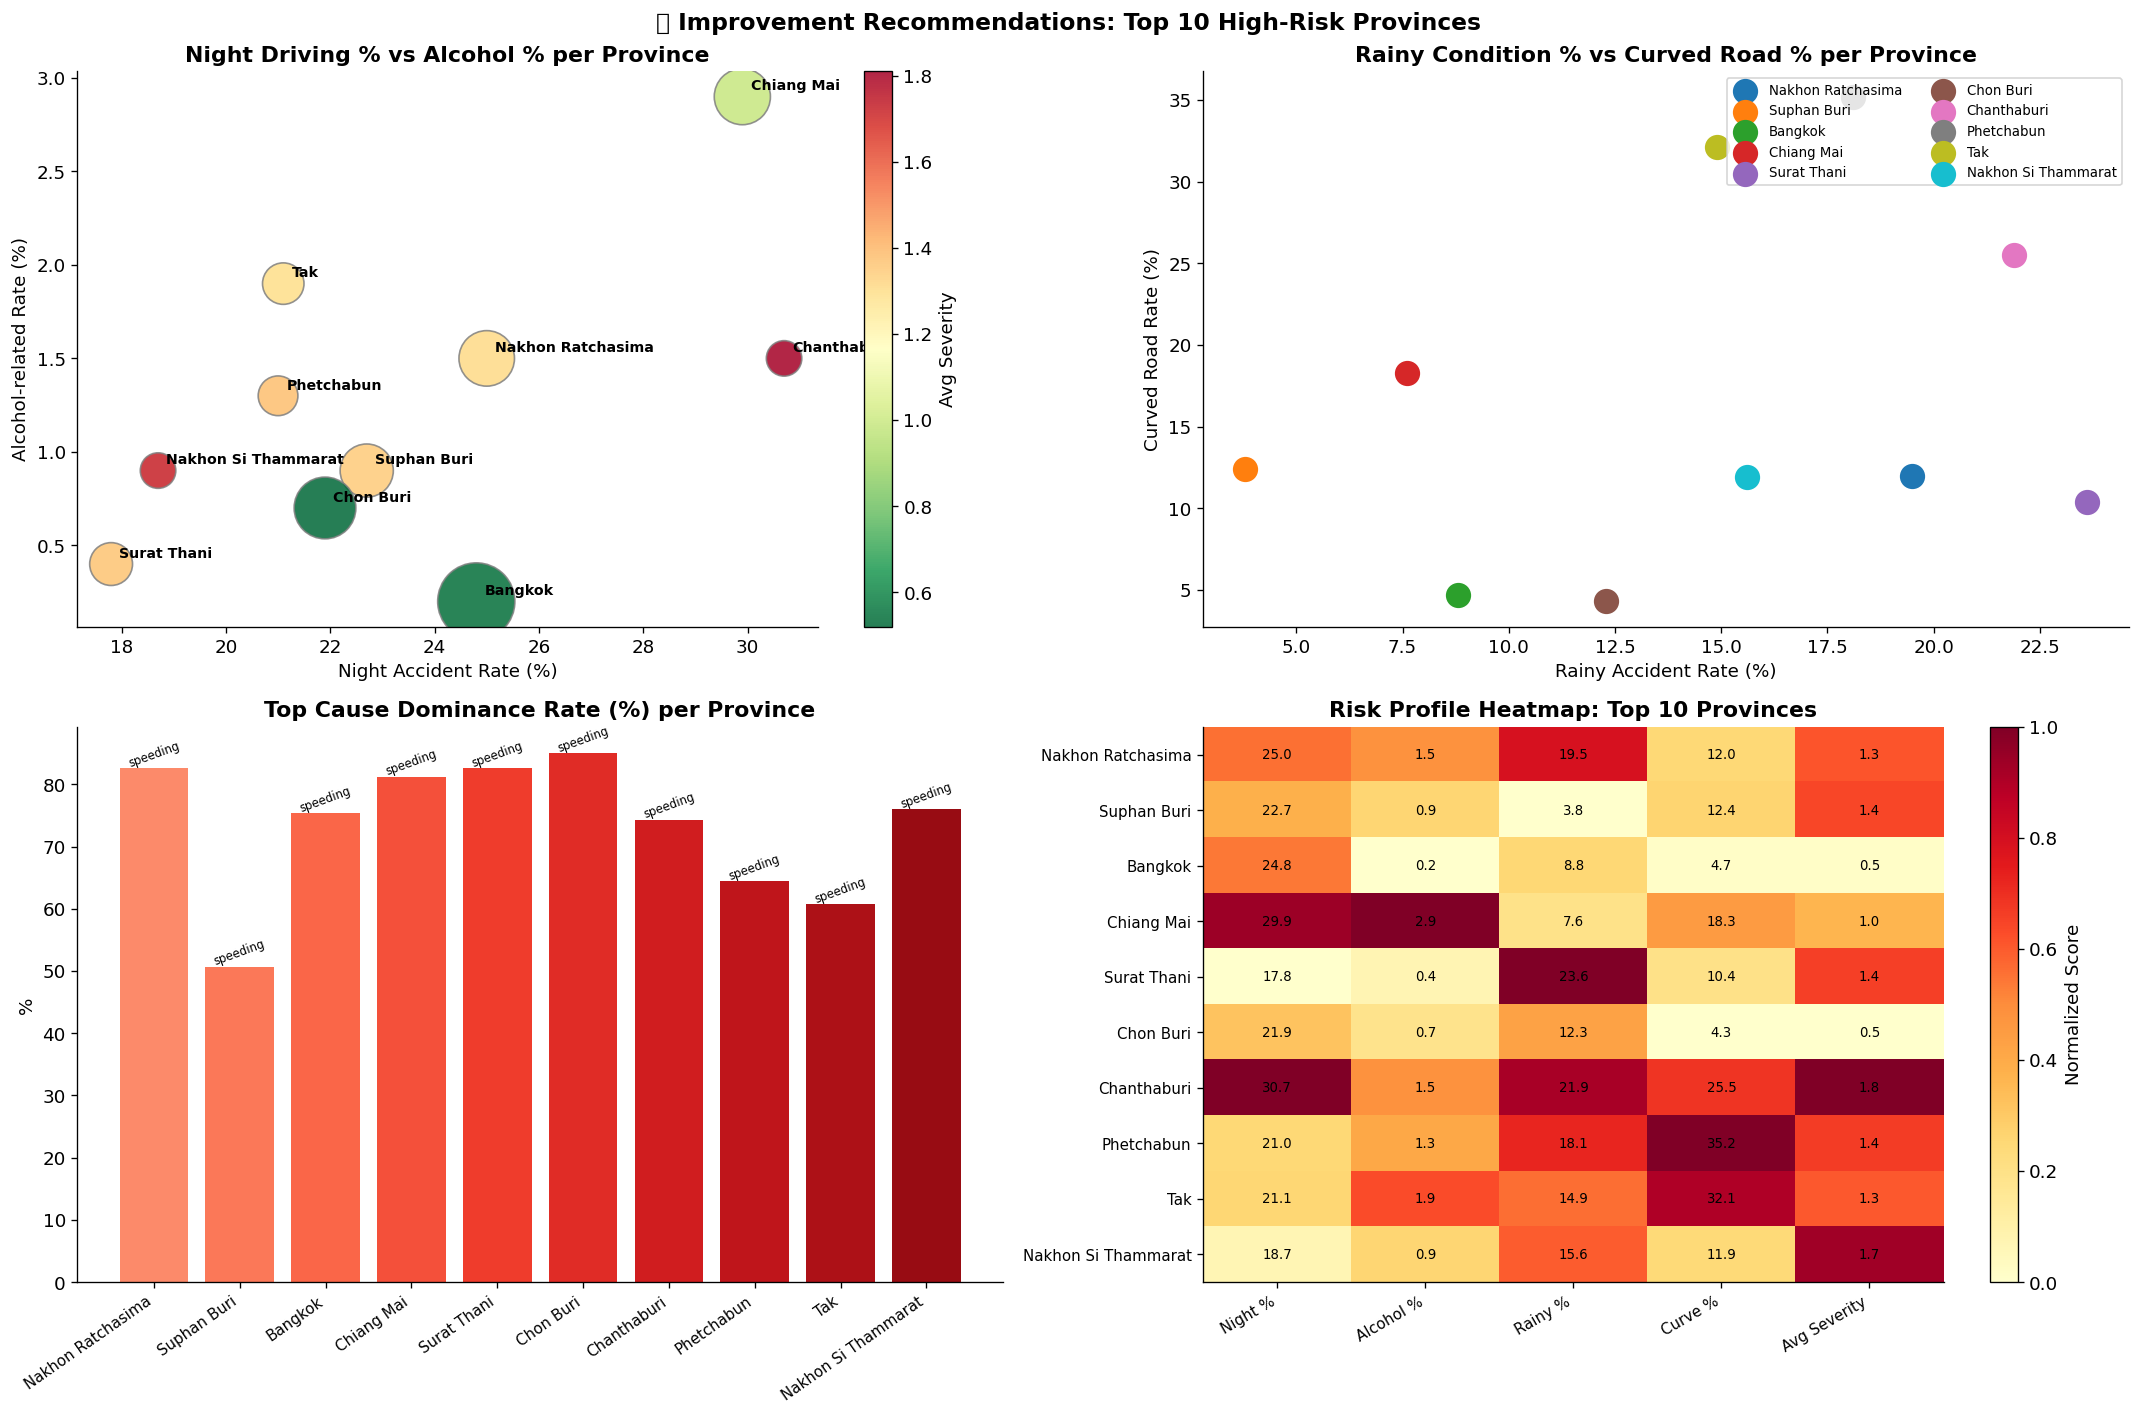


=== IMPROVEMENT RECOMMENDATION TABLE ===
           Province  Total Accidents Top Cause  Cause Rate%          Top Time  Night %  Alcohol %  Rainy %  Curve %  Avg Severity           Top Vehicle
  Nakhon Ratchasima             3330  speeding         82.6   Morning (05-12)     25.0        1.5     19.5     12.0          1.31  4-wheel pickup truck
        Suphan Buri             3056  speeding         50.7   Morning (05-12)     22.7        0.9      3.8     12.4          1.35            motorcycle
            Bangkok             6439  speeding         75.4   Morning (05-12)     24.8        0.2      8.8      4.7          0.54 private/passenger car
         Chiang Mai             3407  speeding         81.2     Night (21-05)     29.9        2.9      7.6     18.3          0.99            motorcycle
        Surat Thani             1983  speeding         82.6 Afternoon (12-17)     17.8        0.4     23.6     10.4          1.37  4-wheel pickup truck
          Chon Buri             4120  speeding

In [ ]:
# วิเคราะห์จุดอ่อนของแต่ละจังหวัดชั้นนำ
top10_prov = prov.nlargest(10, 'risk_index')['province_en'].tolist()

improvement_data = []
for p in top10_prov:
    sub = df[df['province_en']==p]
    total = len(sub)
    row = {
        'Province': p,
        'Total Accidents': total,
        'Top Cause': sub['presumed_cause'].value_counts().idxmax(),
        'Cause Rate%': round(sub['presumed_cause'].value_counts().iloc[0]/total*100,1),
        'Top Time': sub['time_cat'].value_counts().idxmax(),
        'Night %': round((sub['hour'].apply(lambda h: h>=21 or h<5).sum()/total)*100,1),
        'Alcohol %': round((sub['presumed_cause']=='driving under the influence of alcohol').sum()/total*100,1),
        'Rainy %': round((sub['weather_condition']=='rainy').sum()/total*100,1),
        'Curve %': round(sub['road_description'].isin(['wide curve','sharp curve']).sum()/total*100,1),
        'Avg Severity': round(sub['severity_score'].mean(),2),
        'Top Vehicle': sub['vehicle_type'].value_counts().idxmax(),
    }
    improvement_data.append(row)

imp_df = pd.DataFrame(improvement_data)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('🏥 Improvement Recommendations: Top 10 High-Risk Provinces', fontsize=14, fontweight='bold')

# 1. Night % vs Alcohol %
ax = axes[0,0]
sc = ax.scatter(imp_df['Night %'], imp_df['Alcohol %'],
                s=imp_df['Total Accidents']/3, c=imp_df['Avg Severity'], cmap='RdYlGn_r',
                alpha=0.85, edgecolors='gray', linewidth=1)
for _, row in imp_df.iterrows():
    ax.annotate(row['Province'], (row['Night %'], row['Alcohol %']),
                textcoords='offset points', xytext=(5,4), fontsize=8.5, fontweight='bold')
plt.colorbar(sc, ax=ax, label='Avg Severity')
ax.set_title('Night Driving % vs Alcohol % per Province', fontweight='bold')
ax.set_xlabel('Night Accident Rate (%)'); ax.set_ylabel('Alcohol-related Rate (%)')

# 2. Rainy% vs Curve%
ax = axes[0,1]
colors_10 = plt.cm.tab10(np.linspace(0,1,10))
for i, (_, row) in enumerate(imp_df.iterrows()):
    ax.scatter(row['Rainy %'], row['Curve %'], s=200, color=colors_10[i], label=row['Province'], zorder=3)
ax.set_title('Rainy Condition % vs Curved Road % per Province', fontweight='bold')
ax.set_xlabel('Rainy Accident Rate (%)'); ax.set_ylabel('Curved Road Rate (%)')
ax.legend(fontsize=8, loc='upper right', ncol=2)

# 3. Cause Rate bar
ax = axes[1,0]
bars = ax.bar(imp_df['Province'], imp_df['Cause Rate%'],
              color=plt.cm.Reds(np.linspace(0.4, 0.9, len(imp_df))))
ax.set_xticklabels(imp_df['Province'], rotation=35, ha='right', fontsize=9)
ax.set_title('Top Cause Dominance Rate (%) per Province', fontweight='bold')
ax.set_ylabel('%')
for bar, val, cause in zip(bars, imp_df['Cause Rate%'], imp_df['Top Cause']):
    short = cause[:15]+'...' if len(cause)>15 else cause
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, short,
            ha='center', fontsize=7, rotation=20)

# 4. Summary heatmap
ax = axes[1,1]
heat_cols = ['Night %','Alcohol %','Rainy %','Curve %','Avg Severity']
heat_data = imp_df[heat_cols].values
# Normalize per column
heat_norm = (heat_data - heat_data.min(axis=0)) / (heat_data.max(axis=0) - heat_data.min(axis=0) + 1e-9)
im = ax.imshow(heat_norm, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(heat_cols))); ax.set_xticklabels(heat_cols, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(imp_df))); ax.set_yticklabels(imp_df['Province'], fontsize=9)
for i in range(len(imp_df)):
    for j in range(len(heat_cols)):
        ax.text(j, i, f'{heat_data[i,j]:.1f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Normalized Score')
ax.set_title('Risk Profile Heatmap: Top 10 Provinces', fontweight='bold')

plt.tight_layout()
plt.savefig('09_improvement.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n=== IMPROVEMENT RECOMMENDATION TABLE ===')
print(imp_df.to_string(index=False))

## 1️⃣1️⃣ สรุปผลการวิเคราะห์ (Final Summary Dashboard)

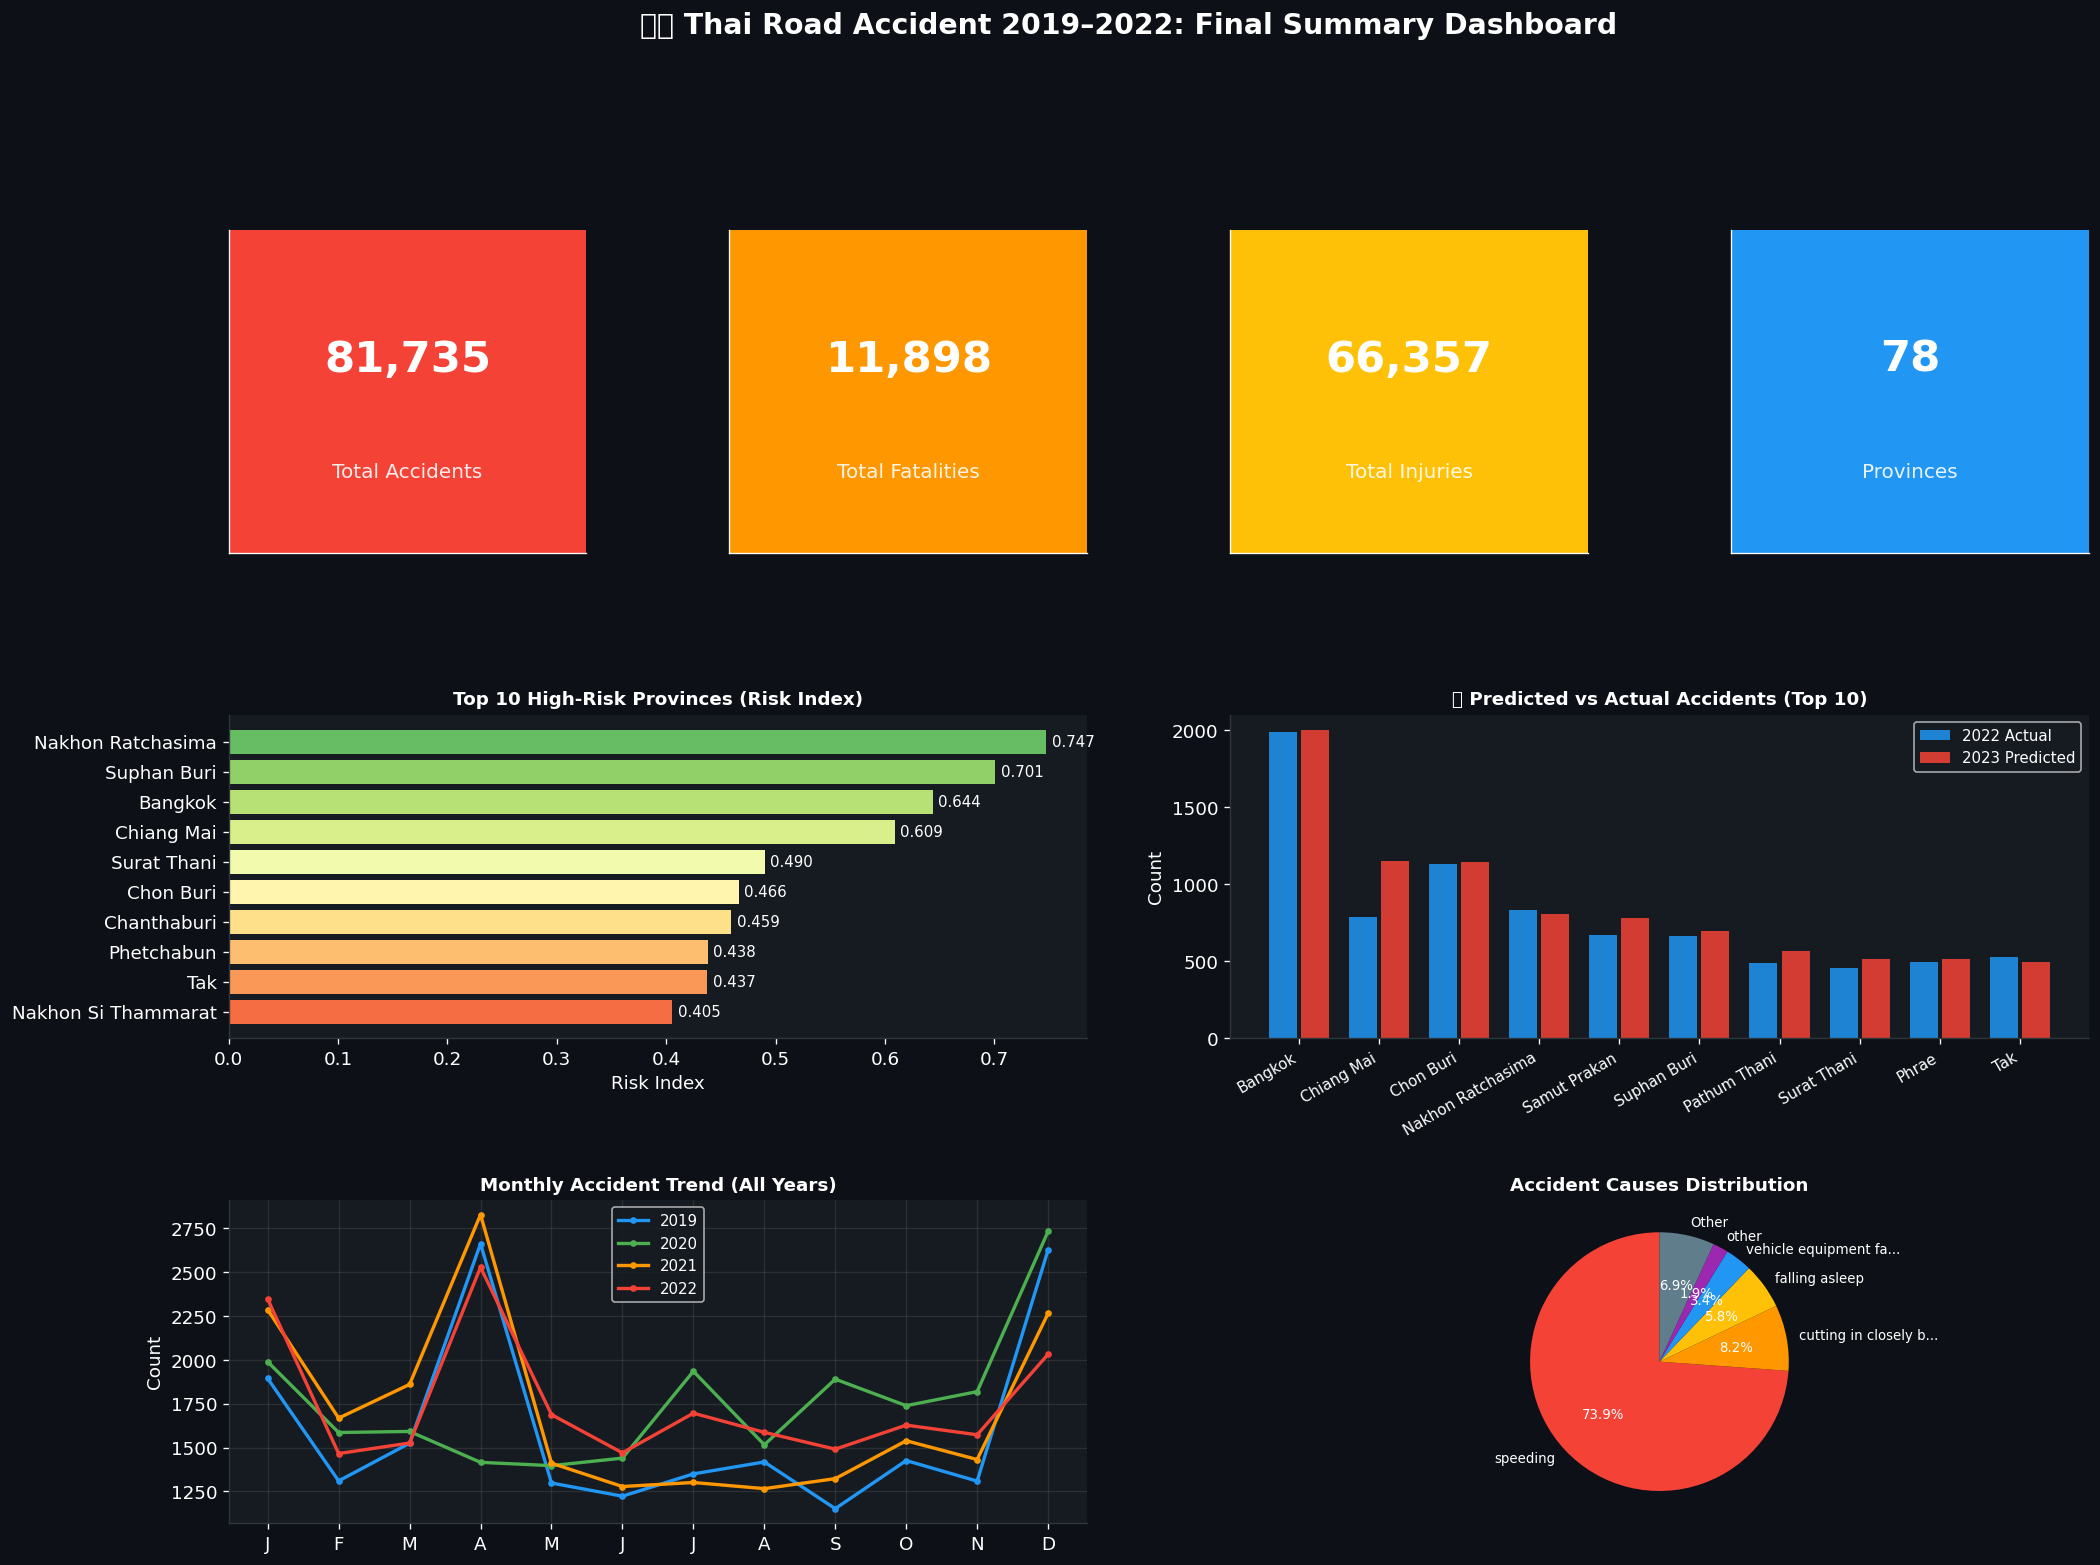

✅ Final summary dashboard saved


In [ ]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle('🇹🇭 Thai Road Accident 2019–2022: Final Summary Dashboard',
             fontsize=17, fontweight='bold', color='white', y=1.01)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

def dark_ax(ax):
    ax.set_facecolor('#161b22')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values(): spine.set_color('#30363d')

# KPI boxes
kpis = [
    (f"{df['acc_code'].nunique():,}", 'Total Accidents', '#F44336'),
    (f"{df['number_of_fatalities'].sum():,}", 'Total Fatalities', '#FF9800'),
    (f"{df['number_of_injuries'].sum():,}", 'Total Injuries', '#FFC107'),
    (f"{df['province_en'].nunique()}", 'Provinces', '#2196F3'),
]
for i, (val, label, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.6, val, ha='center', va='center', fontsize=26, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=12, color='white', alpha=0.9, transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_color('white')

# Top 10 Provinces by Risk
ax = fig.add_subplot(gs[1, :2])
dark_ax(ax)
t10 = prov.nlargest(10, 'risk_index')
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, 10))
bars = ax.barh(t10['province_en'][::-1], t10['risk_index'][::-1], color=colors_bar[::-1])
for bar, val in zip(bars, t10['risk_index'].values[::-1]):
    ax.text(bar.get_width()+0.005, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', color='white', fontsize=9)
ax.set_title('Top 10 High-Risk Provinces (Risk Index)', fontweight='bold', fontsize=11)
ax.set_xlabel('Risk Index')

# Prediction 2023 Top 10
ax = fig.add_subplot(gs[1, 2:])
dark_ax(ax)
t10_pred = pred_df.head(10)
x = np.arange(len(t10_pred))
ax.bar(x-0.2, t10_pred['actual_2022'], 0.35, label='2022 Actual', color='#2196F3', alpha=0.85)
ax.bar(x+0.2, t10_pred['pred_2023'], 0.35, label='2023 Predicted', color='#F44336', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(t10_pred['province'], rotation=30, ha='right', fontsize=9, color='white')
ax.set_title('🔮 Predicted vs Actual Accidents (Top 10)', fontweight='bold', fontsize=11)
ax.legend(facecolor='#161b22', labelcolor='white', fontsize=9)
ax.set_ylabel('Count')

# Monthly trend
ax = fig.add_subplot(gs[2, :2])
dark_ax(ax)
all_monthly = df.groupby(['year','month']).size().reset_index(name='count')
for yr, color in [(2019,'#2196F3'),(2020,'#4CAF50'),(2021,'#FF9800'),(2022,'#F44336')]:
    ym = all_monthly[all_monthly['year']==yr].set_index('month')['count'].reindex(range(1,13),fill_value=0)
    ax.plot(range(1,13), ym.values, color=color, linewidth=2, label=str(yr), marker='.')
ax.set_title('Monthly Accident Trend (All Years)', fontweight='bold', fontsize=11)
ax.set_xticks(range(1,13)); ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.legend(facecolor='#161b22', labelcolor='white', fontsize=9)
ax.set_ylabel('Count'); ax.grid(alpha=0.2, color='gray')

# Cause pie
ax = fig.add_subplot(gs[2, 2:])
ax.set_facecolor('#161b22')
top_causes = df['presumed_cause'].value_counts().head(5)
other = df['presumed_cause'].value_counts().iloc[5:].sum()
vals = list(top_causes.values) + [other]
lbls = [c[:20]+'...' if len(c)>20 else c for c in top_causes.index] + ['Other']
colors_pie = ['#F44336','#FF9800','#FFC107','#2196F3','#9C27B0','#607D8B']
wedges, texts, autotexts = ax.pie(vals, labels=lbls, autopct='%1.1f%%',
                                   colors=colors_pie, startangle=90,
                                   textprops={'color':'white','fontsize':8})
for at in autotexts: at.set_color('white'); at.set_fontsize(8)
ax.set_title('Accident Causes Distribution', fontweight='bold', fontsize=11, color='white')

plt.savefig('10_summary_dashboard.png', bbox_inches='tight', dpi=150, facecolor=fig.get_facecolor())
plt.show()
print('✅ Final summary dashboard saved')

## 1️⃣2️⃣ 📋 สรุปข้อเสนอแนะการปรับปรุงแต่ละพื้นที่

In [ ]:
print('=' * 90)
print('📋 IMPROVEMENT RECOMMENDATIONS BY HIGH-RISK PROVINCE')
print('   (Based on Thai Road Accident Analysis 2019–2022)')
print('=' * 90)

rec_template = {
    'speeding': '🚦 ติดกล้องตรวจจับความเร็วเพิ่มเติม / เพิ่มป้ายเตือน / ลดขีดจำกัดความเร็วในจุดเสี่ยง',
    'falling asleep': '💤 ติดตั้งไฟเตือนอาการง่วงบนถนนสายหลัก / เพิ่มจุดพักรถ (Rest Area) ทุก 100 กม.',
    'driving under the influence of alcohol': '🍺 เพิ่มด่านตรวจวัดแอลกอฮอล์ในช่วงกลางคืน-วันหยุด / รณรงค์ "ไม่ดื่มไม่ขับ"',
    'cutting in closely by people/vehicles/animals': '⚠️ ปรับปรุงทัศนวิสัย / ป้ายเตือนสัตว์ข้ามถนน / ไฟถนนให้ครบ',
    'vehicle equipment failure': '🔧 เพิ่มความถี่ตรวจสภาพรถบนถนนสายหลัก / จุดพักสำหรับรถบรรทุก',
}

for i, p in enumerate(top10_prov):
    sub = df[df['province_en']==p]
    top_cause = sub['presumed_cause'].value_counts().idxmax()
    top_time = sub['time_cat'].value_counts().idxmax()
    top_road = sub['road_description'].value_counts().idxmax()
    top_veh = sub['vehicle_type'].value_counts().idxmax()
    night_rate = (sub['hour'].apply(lambda h: h>=21 or h<5).mean()*100)
    alc_rate = (sub['presumed_cause']=='driving under the influence of alcohol').mean()*100

    print(f'\n🗺️  {i+1:2d}. {p}')
    print(f'   📊 จำนวนอุบัติเหตุรวม : {len(sub):,} ครั้ง | อุบัติเหตุกลางคืน: {night_rate:.1f}%')
    print(f'   🔑 สาเหตุหลัก        : {top_cause} ({sub["presumed_cause"].value_counts().iloc[0]/len(sub)*100:.1f}%)')
    print(f'   🕐 ช่วงเวลาเสี่ยง    : {top_time}')
    print(f'   🛣️  ลักษณะถนน        : {top_road}')
    print(f'   🚗 ยานพาหนะหลัก     : {top_veh}')
    print(f'   🍺 อุบัติเหตุจากเมา  : {alc_rate:.1f}%')

    # Recommendations
    print(f'   💡 ข้อเสนอแนะ:')
    for cause_key, rec in rec_template.items():
        if cause_key in top_cause.lower() or (cause_key == 'speeding' and 'speed' in top_cause.lower()):
            print(f'      → {rec}')
            break
    else:
        print(f'      → 🔍 ศึกษาสาเหตุเชิงลึกเพิ่มเติม / เพิ่มการลาดตระเวนในช่วงเวลาเสี่ยง')

    if night_rate > 30:
        print(f'      → 💡 ติดตั้งไฟถนนเพิ่มเติมในพื้นที่เสี่ยง (อุบัติเหตุกลางคืนสูง {night_rate:.0f}%)')
    if alc_rate > 2:
        print(f'      → 🚔 เพิ่มด่านตรวจแอลกอฮอล์ (คิดเป็น {alc_rate:.1f}% ของอุบัติเหตุทั้งหมด)')

print('\n' + '=' * 90)
print('🔮 TOP 5 PROVINCES PREDICTED TO HAVE MOST ACCIDENTS IN 2023')
print('=' * 90)
for _, row in pred_df.head(5).iterrows():
    arrow = '📈' if row['slope']>0 else '📉'
    print(f'  {arrow} {row["province"]:<30} → Predicted: {row["pred_2023"]:,} accidents (2022: {row["actual_2022"]:,}, slope: {row["slope"]:+.0f}/yr)')
print('=' * 90)

📋 IMPROVEMENT RECOMMENDATIONS BY HIGH-RISK PROVINCE
   (Based on Thai Road Accident Analysis 2019–2022)

🗺️   1. Nakhon Ratchasima
   📊 จำนวนอุบัติเหตุรวม : 3,330 ครั้ง | อุบัติเหตุกลางคืน: 25.0%
   🔑 สาเหตุหลัก        : speeding (82.6%)
   🕐 ช่วงเวลาเสี่ยง    : Morning (05-12)
   🛣️  ลักษณะถนน        : straight road
   🚗 ยานพาหนะหลัก     : 4-wheel pickup truck
   🍺 อุบัติเหตุจากเมา  : 1.5%
   💡 ข้อเสนอแนะ:
      → 🚦 ติดกล้องตรวจจับความเร็วเพิ่มเติม / เพิ่มป้ายเตือน / ลดขีดจำกัดความเร็วในจุดเสี่ยง

🗺️   2. Suphan Buri
   📊 จำนวนอุบัติเหตุรวม : 3,056 ครั้ง | อุบัติเหตุกลางคืน: 22.7%
   🔑 สาเหตุหลัก        : speeding (50.7%)
   🕐 ช่วงเวลาเสี่ยง    : Morning (05-12)
   🛣️  ลักษณะถนน        : straight road
   🚗 ยานพาหนะหลัก     : motorcycle
   🍺 อุบัติเหตุจากเมา  : 0.9%
   💡 ข้อเสนอแนะ:
      → 🚦 ติดกล้องตรวจจับความเร็วเพิ่มเติม / เพิ่มป้ายเตือน / ลดขีดจำกัดความเร็วในจุดเสี่ยง

🗺️   3. Bangkok
   📊 จำนวนอุบัติเหตุรวม : 6,439 ครั้ง | อุบัติเหตุกลางคืน: 24.8%
   🔑 สาเหตุหลัก        : speedin